In [2]:
import os
from dotenv import load_dotenv
import pandas as pd
load_dotenv()

True

In [3]:
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

## Langsmith Tracking and tracing

os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")

# Loading the dataframe 🚀

In [5]:
file_path = "/Users/sivasubramanians/Santhosh/Projects/Agentic AI/1-Langchain/Lanchain_Data_analysis/data_set.xlsx"
df=pd.read_excel(file_path)
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education_Level,EducationField,BusinessTravel,Department,Commute,MonthlyIncome,...,Role,Satisfaction,NumCompaniesWorked,OverTime,TotalExperienceYears,YearsInCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithLineManager,Attrition
0,1,41,Female,Single,2,Social Sciences,rarely,Sales,1,5993,...,Sales Executive,4,8,Yes,8,6,4,0,5,Yes
1,2,49,Male,Married,1,Social Sciences,frequently,Research & Development,8,5130,...,Research Scientist,2,1,No,10,10,7,1,7,No
2,4,37,Male,Single,2,Other,rarely,Research & Development,2,2090,...,Laboratory Technician,3,6,Yes,7,0,0,0,0,Yes
3,5,33,Female,Married,4,Social Sciences,frequently,Research & Development,3,2909,...,Research Scientist,3,1,Yes,8,8,7,3,0,No
4,7,27,Male,Married,1,Health Science,rarely,Research & Development,2,3468,...,Laboratory Technician,2,9,No,6,2,2,2,2,No


# Initializing the model 🚀

In [4]:
from langchain_groq import ChatGroq
from langchain.schema import HumanMessage

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

g_llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0
)

# g_llm.predict_messages([HumanMessage(content="hello who are you?")])

/Users/sivasubramanians/Santhosh/Projects/Agentic AI/1-Langchain/langchain_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [5]:
from langchain_core.prompts import ChatPromptTemplate

data_analyst_prompt=ChatPromptTemplate.from_messages(
    [
        ("system","You are an expert Data Analyst. provide me only the calculation code and no load dataframe function and Provide me answer based on the question"),
        ("user","{input}")

    ]
)
data_analyst_prompt


ChatPromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an expert Data Analyst. provide me only the calculation code and no load dataframe function and Provide me answer based on the question'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])

In [ ]:
# execution_context = {"df": df}  # Store df
# exec(eda_code, globals(), execution_context)  # Run EDA

In [6]:
chain=data_analyst_prompt|g_llm 

response=chain.invoke({"input":f"Can you tell me department and role wise monthly income from the dataset{df}?"})
print(response.content)

```python
# Calculate department and role wise monthly income
department_role_income = df.groupby(['Department', 'Role'])['MonthlyIncome'].mean().reset_index()

# Print the result
print(department_role_income)
```


In [7]:
from langchain_core.tools import Tool
from langchain_experimental.utilities import PythonREPL
import re

# Create a Python REPL tool
python_repl=PythonREPL()

python_repl.run(f"import pandas as pd\ndf = pd.DataFrame({df.to_dict()})")
# ✅ Directly execute the extracted code
execution_result = python_repl.run(response.content)

# Print the execution result
print("Execution Result:\n", execution_result)

Python REPL can execute arbitrary code. Use with caution.


Execution Result:
                 Department                       Role  MonthlyIncome
0          Human Resources            Human Resources    4235.750000
1          Human Resources                    Manager   18088.636364
2   Research & Development  Healthcare Representative    7528.763359
3   Research & Development      Laboratory Technician    3237.169884
4   Research & Development                    Manager   17130.333333
5   Research & Development     Manufacturing Director    7295.137931
6   Research & Development          Research Director   16033.550000
7   Research & Development         Research Scientist    3239.972603
8                    Sales                    Manager   16986.972973
9                    Sales            Sales Executive    6924.279141
10                   Sales       Sales Representative    2626.000000



In [8]:
df.groupby(["Department","Role"])["MonthlyIncome"].mean()

Department              Role                     
Human Resources         Human Resources               4235.750000
                        Manager                      18088.636364
Research & Development  Healthcare Representative     7528.763359
                        Laboratory Technician         3237.169884
                        Manager                      17130.333333
                        Manufacturing Director        7295.137931
                        Research Director            16033.550000
                        Research Scientist            3239.972603
Sales                   Manager                      16986.972973
                        Sales Executive               6924.279141
                        Sales Representative          2626.000000
Name: MonthlyIncome, dtype: float64

In [9]:
response2=chain.invoke({"input":f"Can you plot the department wise monthly Income from the dataset {df}? "})
print(response2.content)

```python
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
department_wise_income = df.groupby('Department')['MonthlyIncome'].sum().reset_index()

# Plotting the department wise monthly income
plt.figure(figsize=(10,6))
plt.bar(department_wise_income['Department'], department_wise_income['MonthlyIncome'], color='skyblue')
plt.xlabel('Department')
plt.ylabel('Monthly Income')
plt.title('Department Wise Monthly Income')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
```


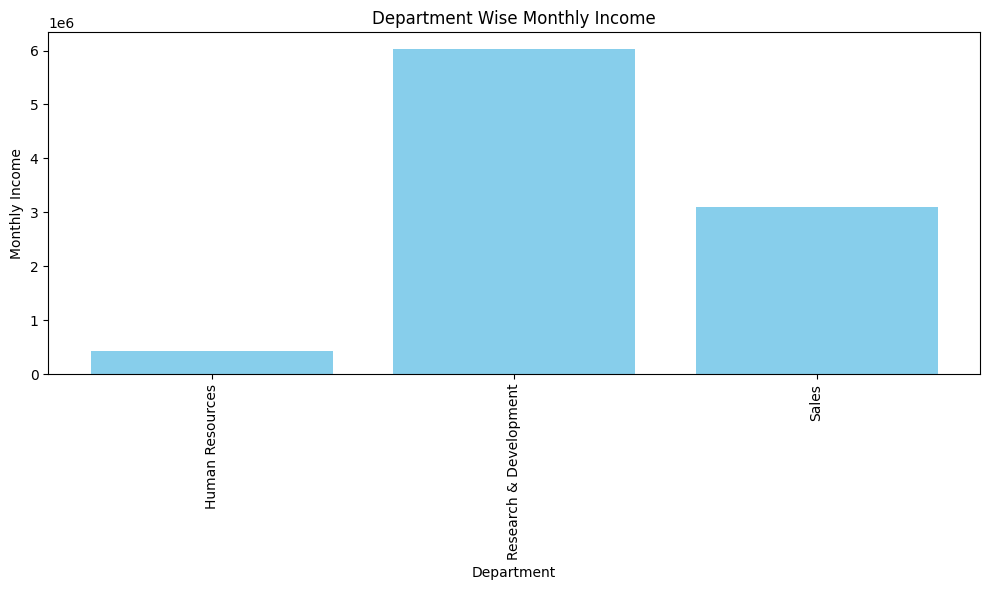

''

In [10]:
python_repl.run(response2.content)

In [18]:
response3=chain.invoke({"input":f"Can you plot the total department wise monthly Income from the dataset and use plotly to plot and display the monthly income in the plot{df}? "})
print(response3.content)

python_repl.run(response3.content)

```python
import plotly.express as px

# Calculate total department wise monthly income
department_wise_income = df.groupby('Department')['MonthlyIncome'].sum().reset_index()

# Plot the data
fig = px.bar(department_wise_income, x='Department', y='MonthlyIncome', title='Department Wise Monthly Income')
fig.show()
```


''

In [19]:
import plotly.express as px
department_wise_income = df.groupby('Department')['MonthlyIncome'].sum().reset_index()
fig = px.bar(department_wise_income, x='Department', y='MonthlyIncome', title='Department Wise Monthly Income',text='MonthlyIncome')
fig.update_layout(
    title="Department Wise Monthly Income",
    xaxis_title="Department",
    yaxis_title="Monthly Income"
)
fig.show()

In [21]:
response4=chain.invoke({"input":f"Can you do the neccesary eda and explain the findings in the dataframe, report it to the HR head{df}? "})
print(response4.content)

python_repl.run(response4.content)

To perform the necessary EDA and report the findings to the HR head, I will calculate the following metrics:

```python
# Calculate summary statistics
print("Summary Statistics:")
print(df.describe())

# Calculate employee distribution by department
print("\nEmployee Distribution by Department:")
print(df['Department'].value_counts())

# Calculate employee distribution by job role
print("\nEmployee Distribution by Job Role:")
print(df['Role'].value_counts())

# Calculate average monthly income by department
print("\nAverage Monthly Income by Department:")
print(df.groupby('Department')['MonthlyIncome'].mean())

# Calculate average years of experience by department
print("\nAverage Years of Experience by Department:")
print(df.groupby('Department')['TotalExperienceYears'].mean())

# Calculate employee distribution by attrition status
print("\nEmployee Distribution by Attrition Status:")
print(df['Attrition'].value_counts())

# Calculate average monthly income by attrition status
print("

"SyntaxError('invalid syntax', ('<string>', 1, 4, 'To perform the necessary EDA and report the findings to the HR head, I will calculate the following metrics:\\n'))"

In [23]:
print(response4.content)

To perform the necessary EDA and report the findings to the HR head, I will calculate the following metrics:

```python
# Calculate summary statistics
print("Summary Statistics:")
print(df.describe())

# Calculate employee distribution by department
print("\nEmployee Distribution by Department:")
print(df['Department'].value_counts())

# Calculate employee distribution by job role
print("\nEmployee Distribution by Job Role:")
print(df['Role'].value_counts())

# Calculate average monthly income by department
print("\nAverage Monthly Income by Department:")
print(df.groupby('Department')['MonthlyIncome'].mean())

# Calculate average years of experience by department
print("\nAverage Years of Experience by Department:")
print(df.groupby('Department')['TotalExperienceYears'].mean())

# Calculate employee distribution by attrition status
print("\nEmployee Distribution by Attrition Status:")
print(df['Attrition'].value_counts())

# Calculate average monthly income by attrition status
print("

In [28]:
eda_code = """
def perform_eda(df):
    # Summary statistics
    print("Summary Statistics:")
    print(df.describe())

    # Employee distribution by department
    print("\\nEmployee Distribution by Department:")
    print(df['Department'].value_counts())

    # Employee distribution by job role
    print("\\nEmployee Distribution by Job Role:")
    print(df['Role'].value_counts())

    # Average monthly income by department
    print("\\nAverage Monthly Income by Department:")
    print(df.groupby('Department')['MonthlyIncome'].mean())

    # Average years of experience by department
    print("\\nAverage Years of Experience by Department:")
    print(df.groupby('Department')['TotalExperienceYears'].mean())

    # Employee distribution by attrition status
    print("\\nEmployee Distribution by Attrition Status:")
    print(df['Attrition'].value_counts())

    # Correlation between education level and experience
    print("\\nCorrelation Between Education Level and Experience:")
    print(df.groupby('Education_Level')['TotalExperienceYears'].mean())

# Run EDA
perform_eda(df)
"""

In [30]:
print(python_repl.run(eda_code))

Summary Statistics:
        EmployeeID          Age  Education_Level      Commute  MonthlyIncome  \
count  1470.000000  1470.000000      1470.000000  1470.000000    1470.000000   
mean   1024.865306    36.923810         2.912925     9.192517    6502.931293   
std     602.024335     9.135373         1.024165     8.106864    4707.956783   
min       1.000000    18.000000         1.000000     1.000000    1009.000000   
25%     491.250000    30.000000         2.000000     2.000000    2911.000000   
50%    1020.500000    36.000000         3.000000     7.000000    4919.000000   
75%    1555.750000    43.000000         4.000000    14.000000    8379.000000   
max    2068.000000    60.000000         5.000000    29.000000   19999.000000   

        MonthlyRate    DailyRate   HourlyRate        Grade  Satisfaction  \
count   1470.000000  1470.000000  1470.000000  1470.000000   1470.000000   
mean   14313.103401   802.485714    65.891156     2.063946      2.728571   
std     7117.786044   403.50910

In [20]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education_Level,EducationField,BusinessTravel,Department,Commute,MonthlyIncome,...,Role,Satisfaction,NumCompaniesWorked,OverTime,TotalExperienceYears,YearsInCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithLineManager,Attrition
0,1,41,Female,Single,2,Social Sciences,rarely,Sales,1,5993,...,Sales Executive,4,8,Yes,8,6,4,0,5,Yes
1,2,49,Male,Married,1,Social Sciences,frequently,Research & Development,8,5130,...,Research Scientist,2,1,No,10,10,7,1,7,No
2,4,37,Male,Single,2,Other,rarely,Research & Development,2,2090,...,Laboratory Technician,3,6,Yes,7,0,0,0,0,Yes
3,5,33,Female,Married,4,Social Sciences,frequently,Research & Development,3,2909,...,Research Scientist,3,1,Yes,8,8,7,3,0,No
4,7,27,Male,Married,1,Health Science,rarely,Research & Development,2,3468,...,Laboratory Technician,2,9,No,6,2,2,2,2,No


In [31]:
response5=chain.invoke({"input":f"Can you do the neccesary eda and explain the findings in the dataframe, report it to the HR head{df}? and provide the codes in EDA function "})
print(response5.content)

print(python_repl.run(response5.content))

Here's a comprehensive EDA (Exploratory Data Analysis) function in Python using pandas and matplotlib libraries. This function will provide insights into the distribution of various columns in the dataframe.

```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df):
    # Check for missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Distribution of categorical variables
    categorical_cols = ['Gender', 'MaritalStatus', 'Education_Level', 'EducationField', 'BusinessTravel', 'Department', 'Role', 'OverTime', 'Attrition']
    for col in categorical_cols:
        print(f"Distribution of {col}:")
        print(df[col].value_counts())
        plt.figure(figsize=(10,6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.show()

    # Distribution of numerical variables
    numerical_cols = ['Age', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalExperienceYears', 'YearsInCompany', 'Year

In [39]:
pattern = r"```python\n(.*?)\n```"
code_match = re.search(pattern, response5.content, re.DOTALL)
print(code_match)

if code_match:
    extracted_code = code_match.group(1)  # Get the actual Python code
    print("Extracted Code:\n", extracted_code)

<re.Match object; span=(209, 2097), match='```python\nimport pandas as pd\nimport matplotlib>
Extracted Code:
 import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df):
    # Check for missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Distribution of categorical variables
    categorical_cols = ['Gender', 'MaritalStatus', 'Education_Level', 'EducationField', 'BusinessTravel', 'Department', 'Role', 'OverTime', 'Attrition']
    for col in categorical_cols:
        print(f"Distribution of {col}:")
        print(df[col].value_counts())
        plt.figure(figsize=(10,6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.show()

    # Distribution of numerical variables
    numerical_cols = ['Age', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalExperienceYears', 'YearsInCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithLineManager']
    for col in numerical_cols:
        p

In [42]:
print(python_repl.run(extracted_code))

NameError("name 'plt' is not defined")


Missing Values:
EmployeeID                 0
Age                        0
Gender                     0
MaritalStatus              0
Education_Level            0
EducationField             0
BusinessTravel             0
Department                 0
Commute                    0
MonthlyIncome              0
MonthlyRate                0
DailyRate                  0
HourlyRate                 0
Grade                      0
Role                       0
Satisfaction               0
NumCompaniesWorked         0
OverTime                   0
TotalExperienceYears       0
YearsInCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithLineManager       0
Attrition                  0
dtype: int64
Distribution of Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64


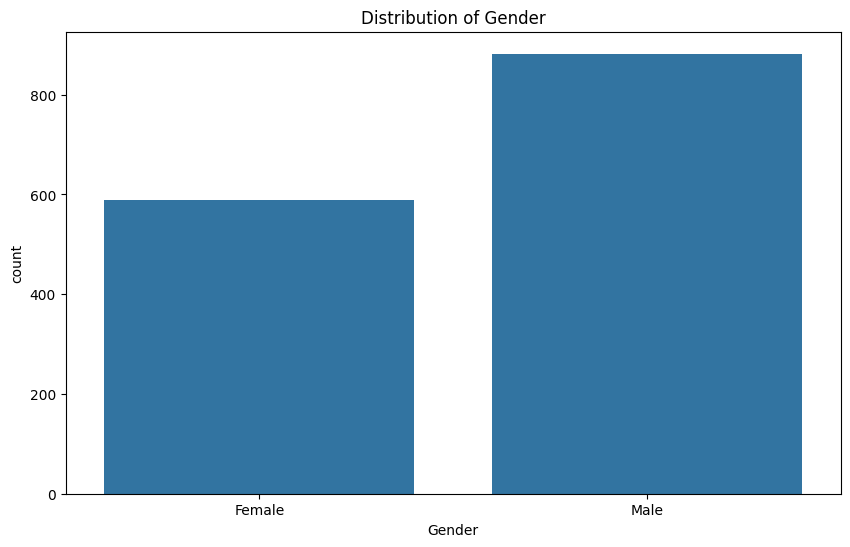

Distribution of MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


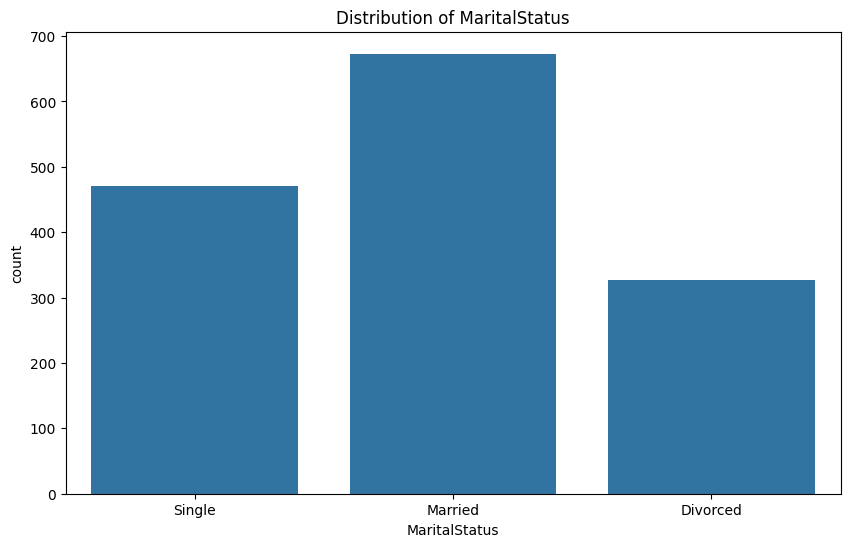

Distribution of Education_Level:
Education_Level
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64


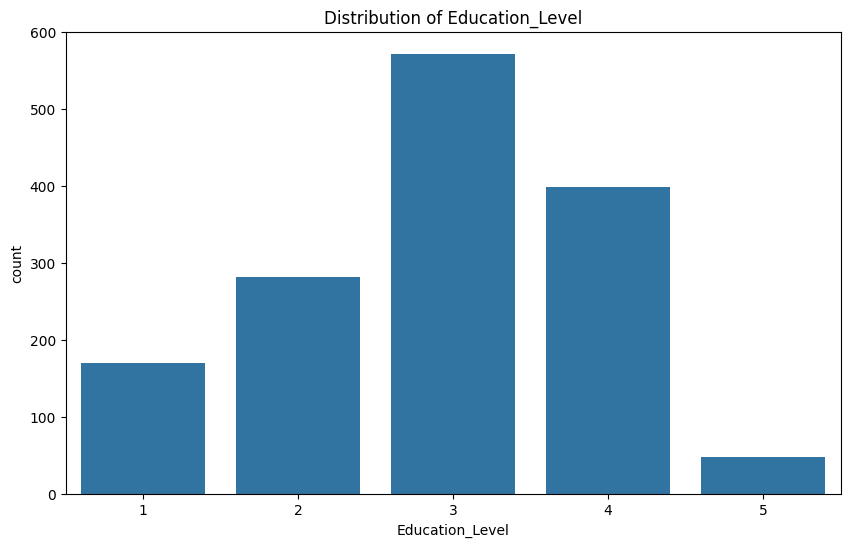

Distribution of EducationField:
EducationField
Social Sciences    606
Health Science     464
Business           159
Engineering        132
Other               82
Human Resources     27
Name: count, dtype: int64


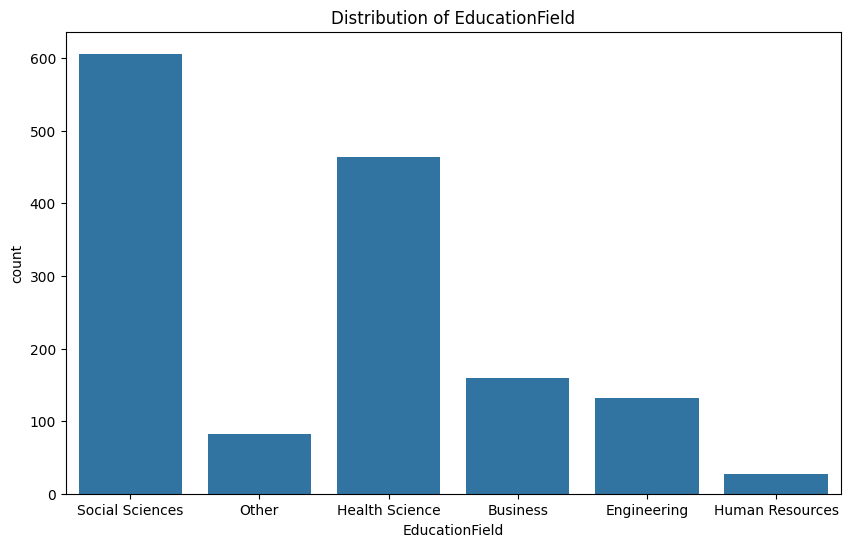

Distribution of BusinessTravel:
BusinessTravel
rarely        1043
frequently     277
none           150
Name: count, dtype: int64


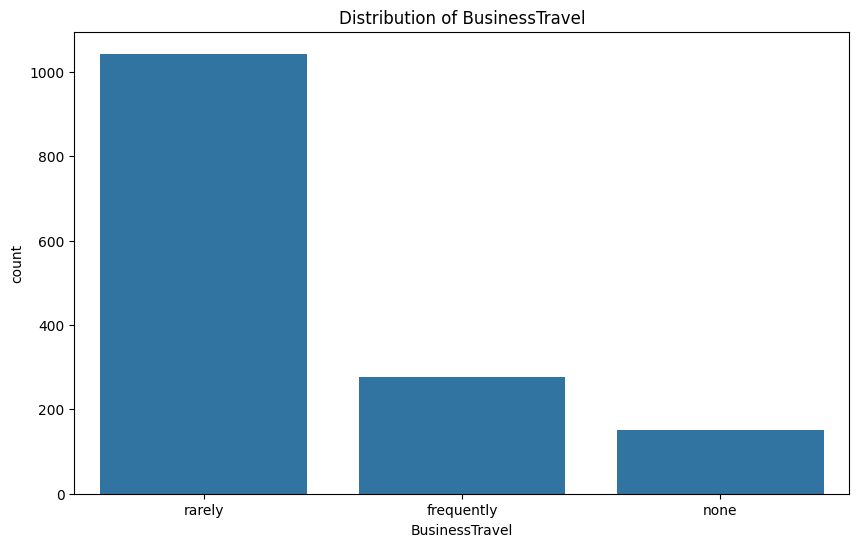

Distribution of Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


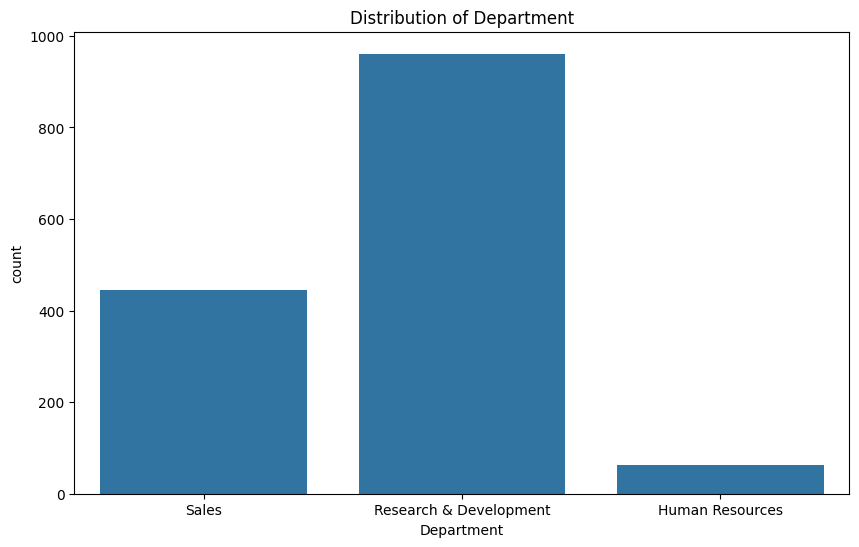

Distribution of Role:
Role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


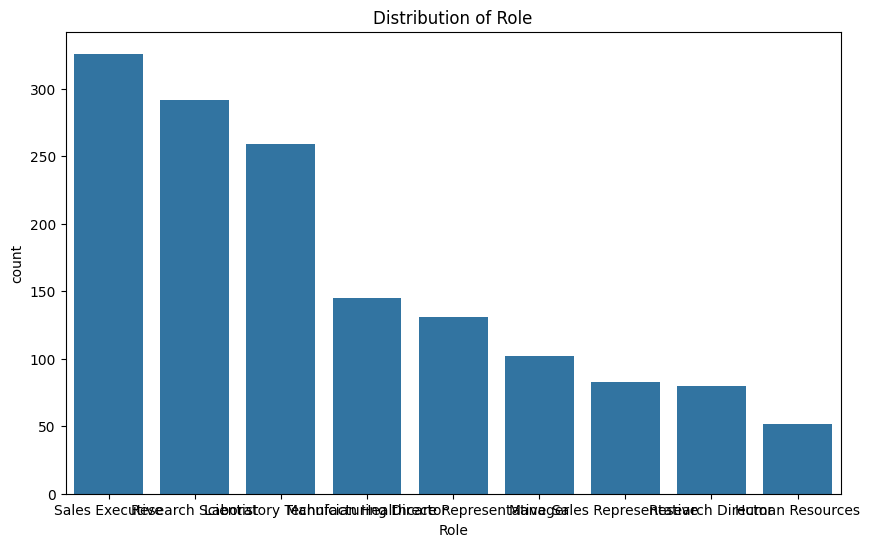

Distribution of OverTime:
OverTime
No     1054
Yes     416
Name: count, dtype: int64


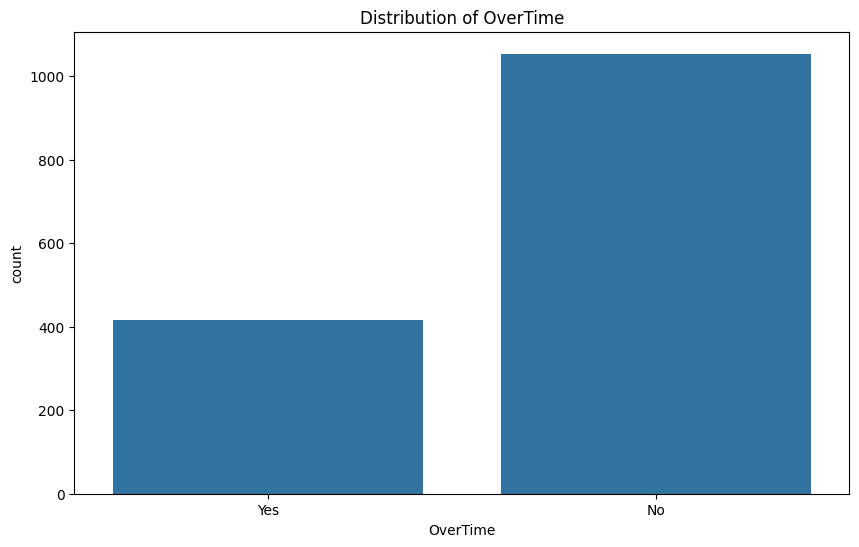

Distribution of Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


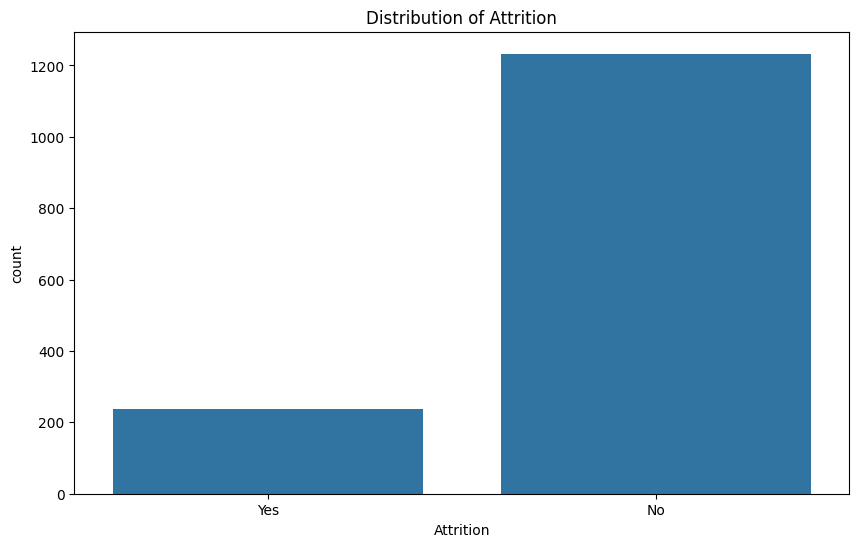

Distribution of Age:
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


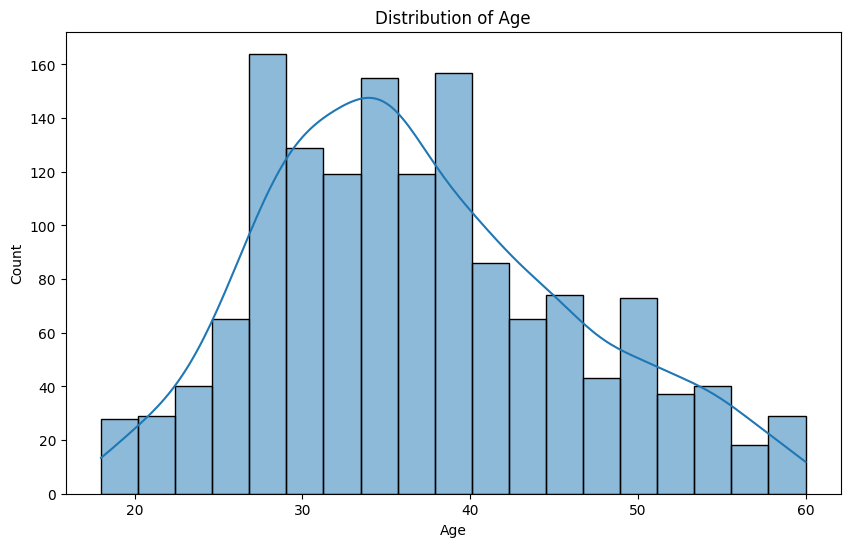

Distribution of MonthlyIncome:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


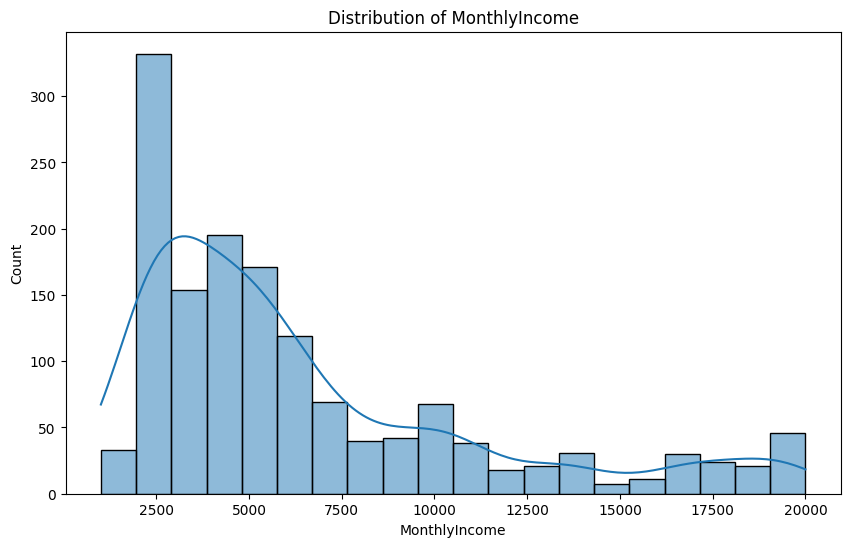

Distribution of NumCompaniesWorked:
count    1470.000000
mean        2.693197
std         2.498009
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         9.000000
Name: NumCompaniesWorked, dtype: float64


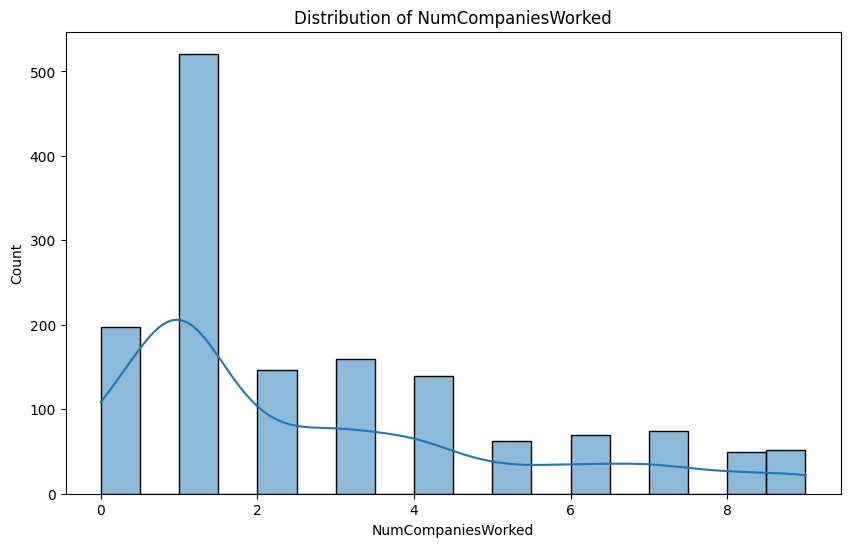

Distribution of TotalExperienceYears:
count    1470.000000
mean       11.279592
std         7.780782
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        40.000000
Name: TotalExperienceYears, dtype: float64


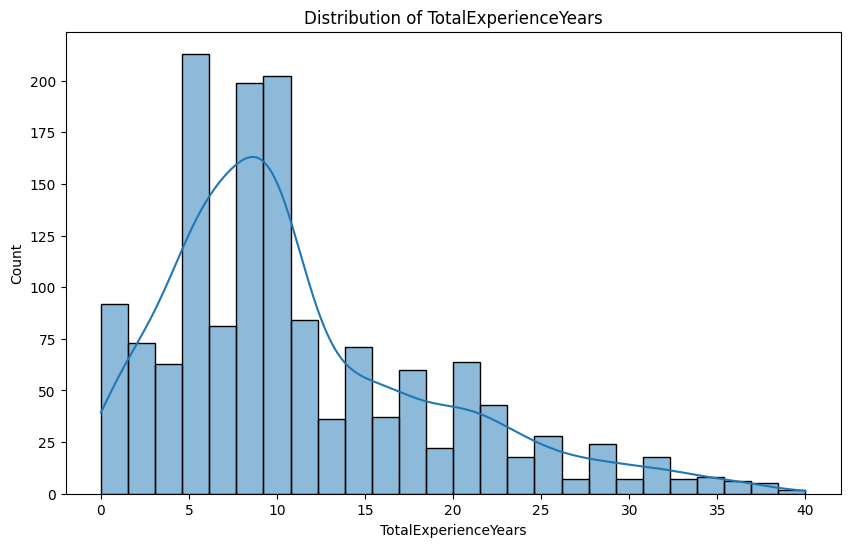

Distribution of YearsInCompany:
count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsInCompany, dtype: float64


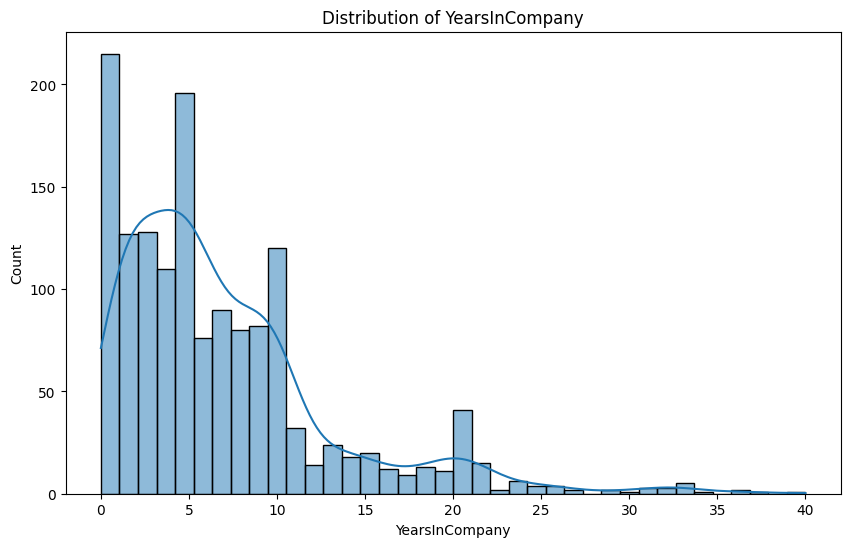

Distribution of YearsInCurrentRole:
count    1470.000000
mean        4.229252
std         3.623137
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        18.000000
Name: YearsInCurrentRole, dtype: float64


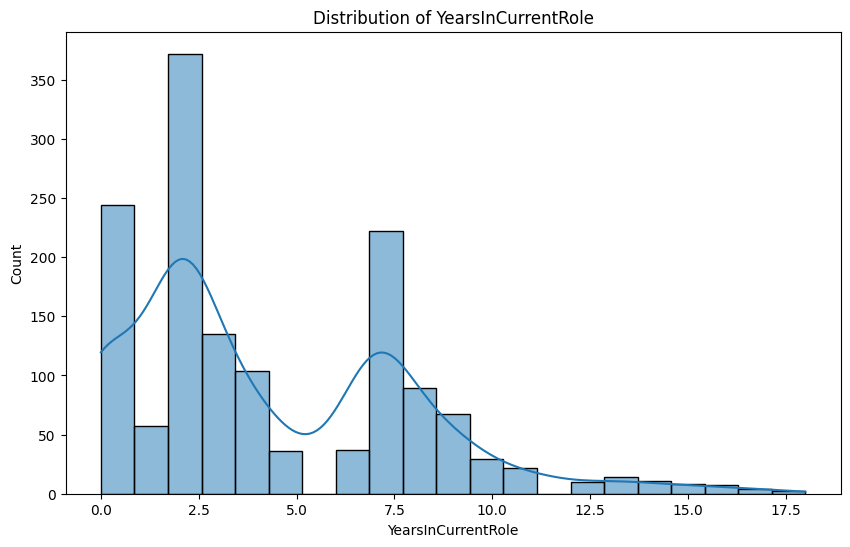

Distribution of YearsSinceLastPromotion:
count    1470.000000
mean        2.187755
std         3.222430
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        15.000000
Name: YearsSinceLastPromotion, dtype: float64


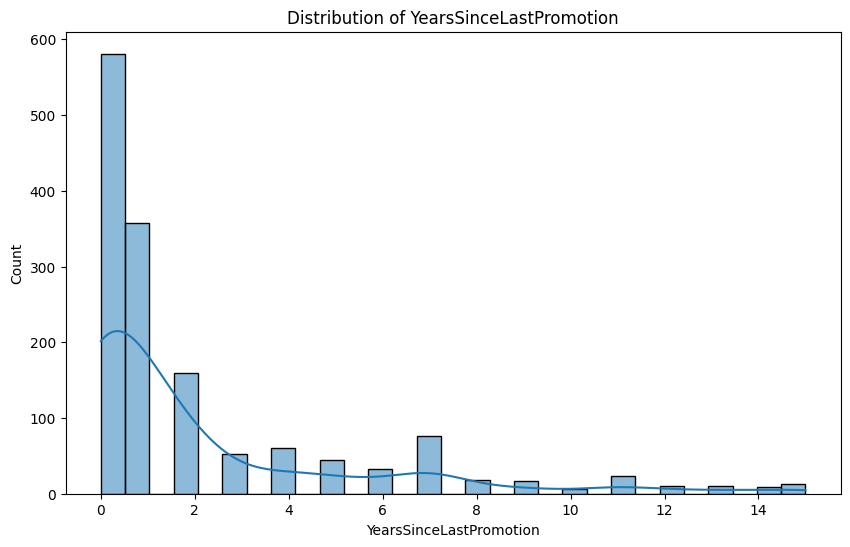

Distribution of YearsWithLineManager:
count    1470.000000
mean        4.123129
std         3.568136
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithLineManager, dtype: float64


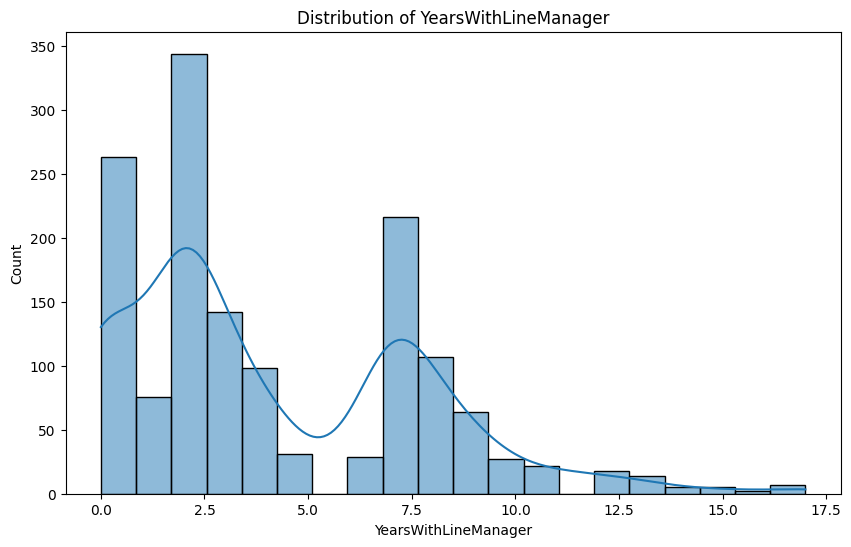

Correlation Matrix:
                              Age  MonthlyIncome  NumCompaniesWorked  \
Age                      1.000000       0.497855            0.299635   
MonthlyIncome            0.497855       1.000000            0.149515   
NumCompaniesWorked       0.299635       0.149515            1.000000   
TotalExperienceYears     0.680381       0.772893            0.237639   
YearsInCompany           0.311309       0.514285           -0.118421   
YearsInCurrentRole       0.212901       0.363818           -0.090754   
YearsSinceLastPromotion  0.216513       0.344978           -0.036814   
YearsWithLineManager     0.202089       0.344079           -0.110319   

                         TotalExperienceYears  YearsInCompany  \
Age                                  0.680381        0.311309   
MonthlyIncome                        0.772893        0.514285   
NumCompaniesWorked                   0.237639       -0.118421   
TotalExperienceYears                 1.000000        0.628133   
YearsI

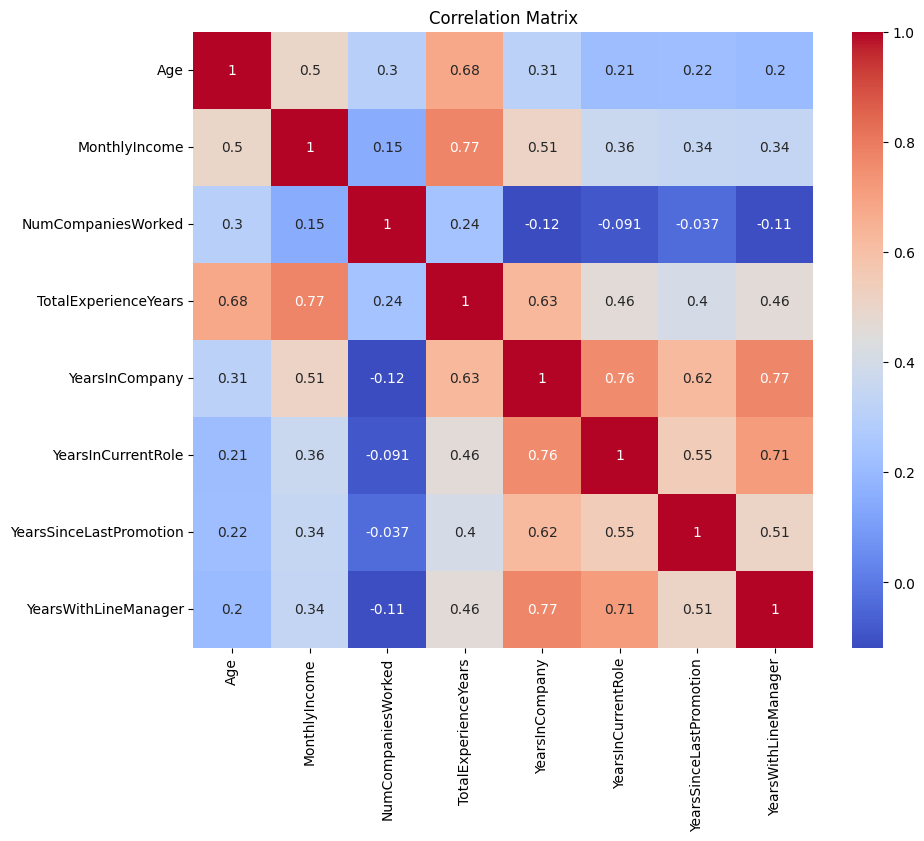

Satisfaction Level Distribution:
Satisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64


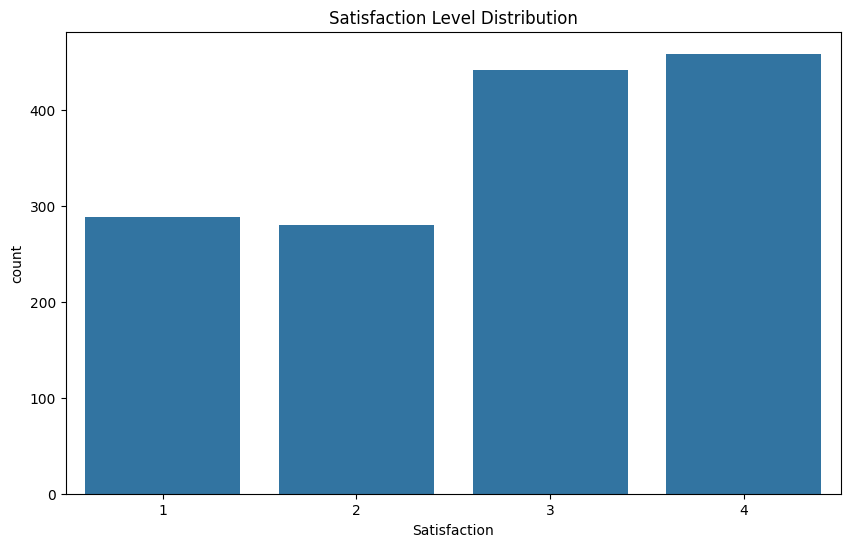

Attrition Rate:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


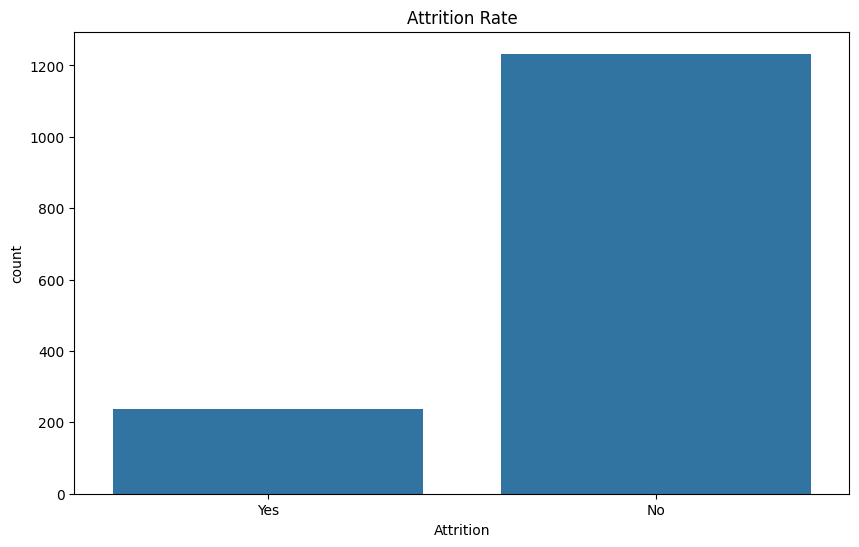

In [43]:
exec(extracted_code)

In [45]:
print(extracted_code)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df):
    # Check for missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Distribution of categorical variables
    categorical_cols = ['Gender', 'MaritalStatus', 'Education_Level', 'EducationField', 'BusinessTravel', 'Department', 'Role', 'OverTime', 'Attrition']
    for col in categorical_cols:
        print(f"Distribution of {col}:")
        print(df[col].value_counts())
        plt.figure(figsize=(10,6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.show()

    # Distribution of numerical variables
    numerical_cols = ['Age', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalExperienceYears', 'YearsInCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithLineManager']
    for col in numerical_cols:
        print(f"Distribution of {col}:")
        print(df[col].describe())
        plt.figure(figsize=(10,6))
        sn

Missing Values:
EmployeeID                 0
Age                        0
Gender                     0
MaritalStatus              0
Education_Level            0
EducationField             0
BusinessTravel             0
Department                 0
Commute                    0
MonthlyIncome              0
MonthlyRate                0
DailyRate                  0
HourlyRate                 0
Grade                      0
Role                       0
Satisfaction               0
NumCompaniesWorked         0
OverTime                   0
TotalExperienceYears       0
YearsInCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithLineManager       0
Attrition                  0
pd                         0
plt                        0
sns                        0
eda                        0
dtype: int64
Distribution of Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64


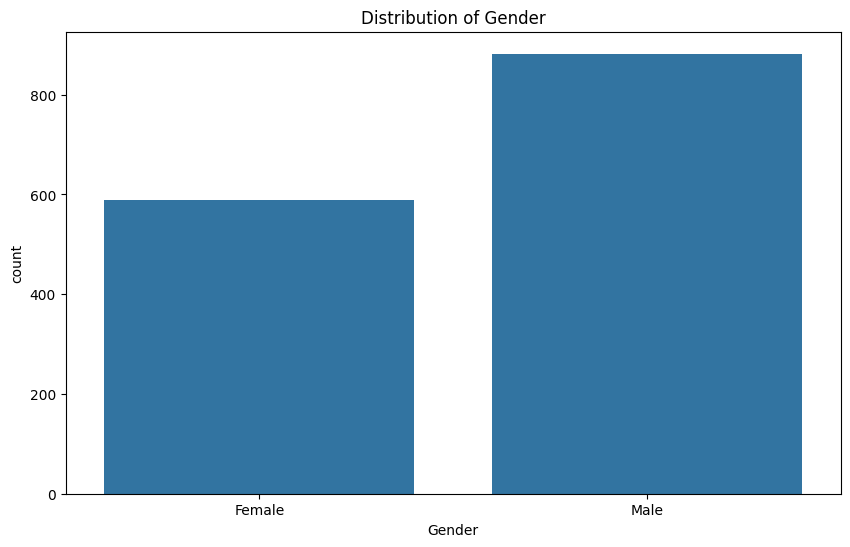

Distribution of MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


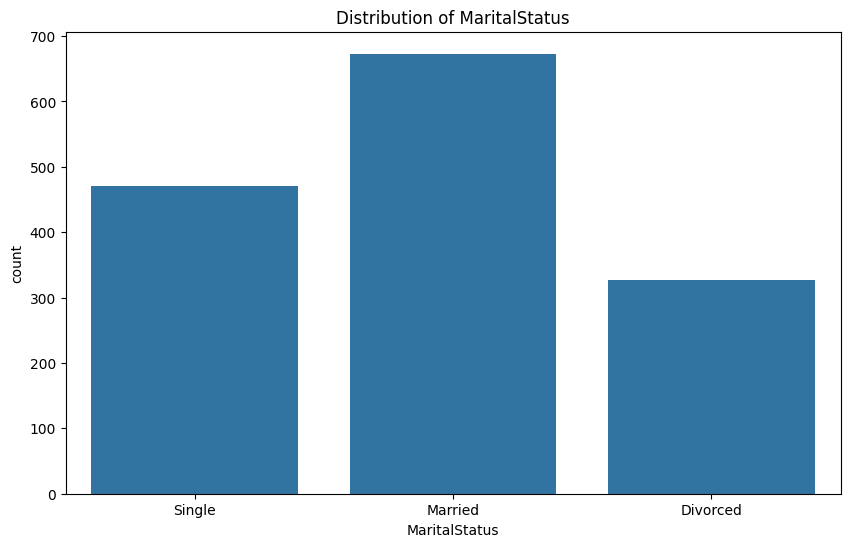

Distribution of Education_Level:
Education_Level
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64


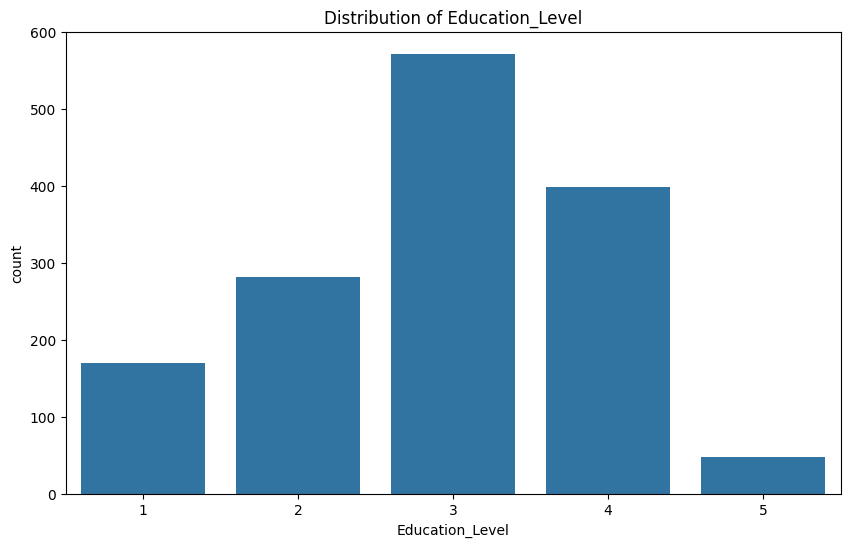

Distribution of EducationField:
EducationField
Social Sciences    606
Health Science     464
Business           159
Engineering        132
Other               82
Human Resources     27
Name: count, dtype: int64


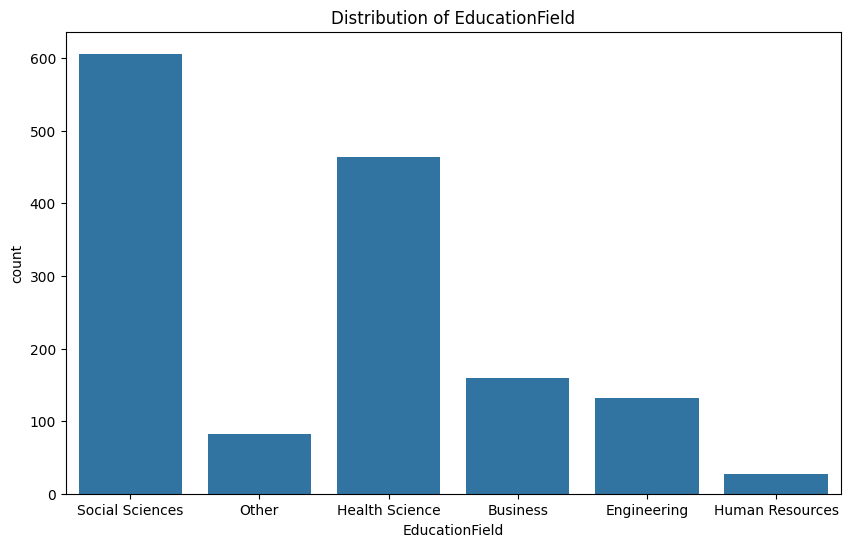

Distribution of BusinessTravel:
BusinessTravel
rarely        1043
frequently     277
none           150
Name: count, dtype: int64


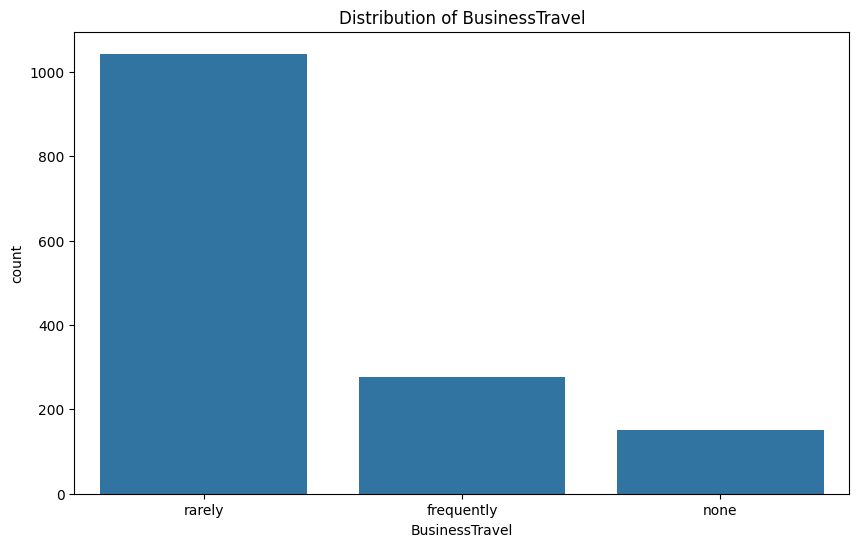

Distribution of Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


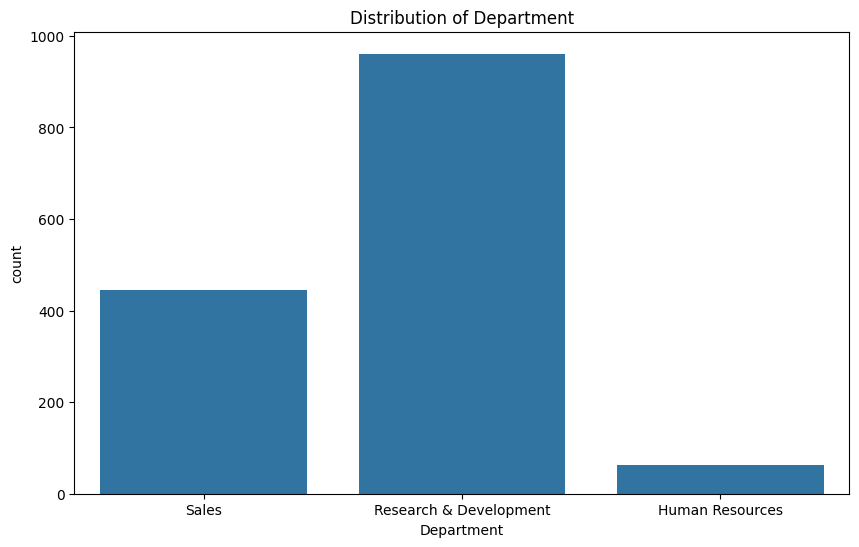

Distribution of Role:
Role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


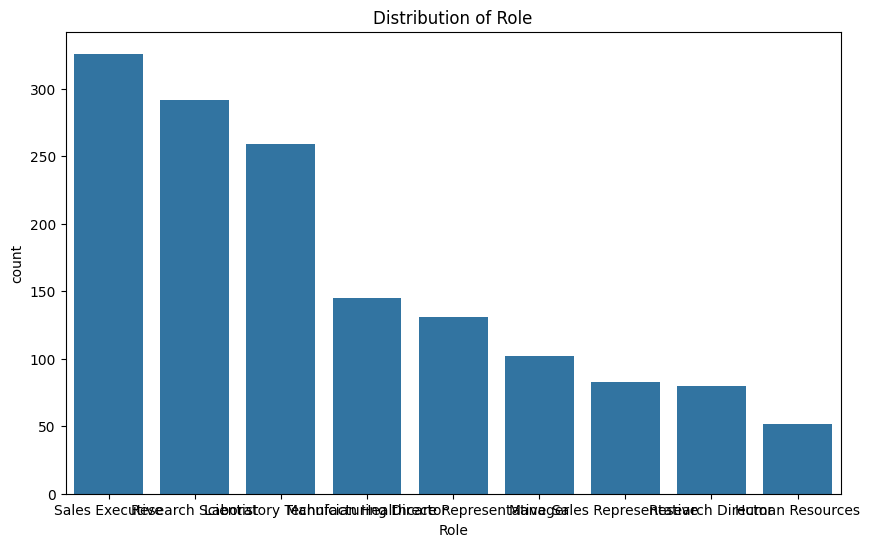

Distribution of OverTime:
OverTime
No     1054
Yes     416
Name: count, dtype: int64


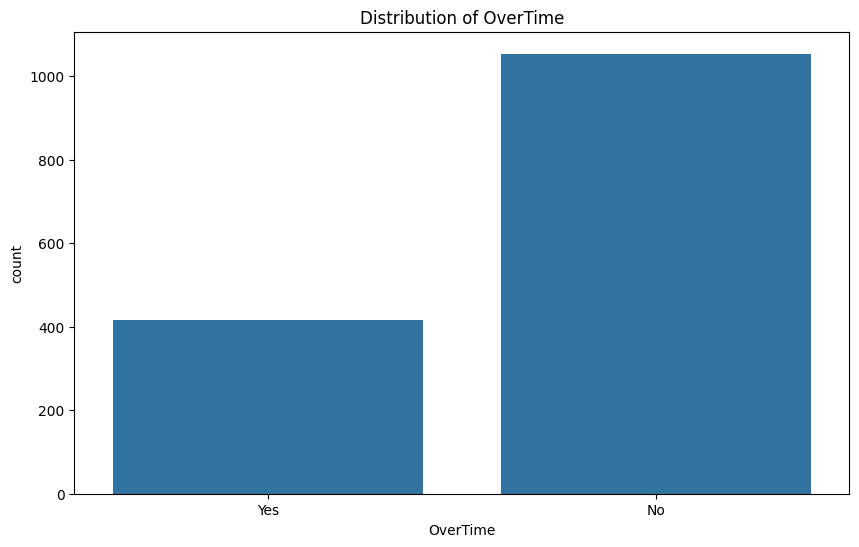

Distribution of Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


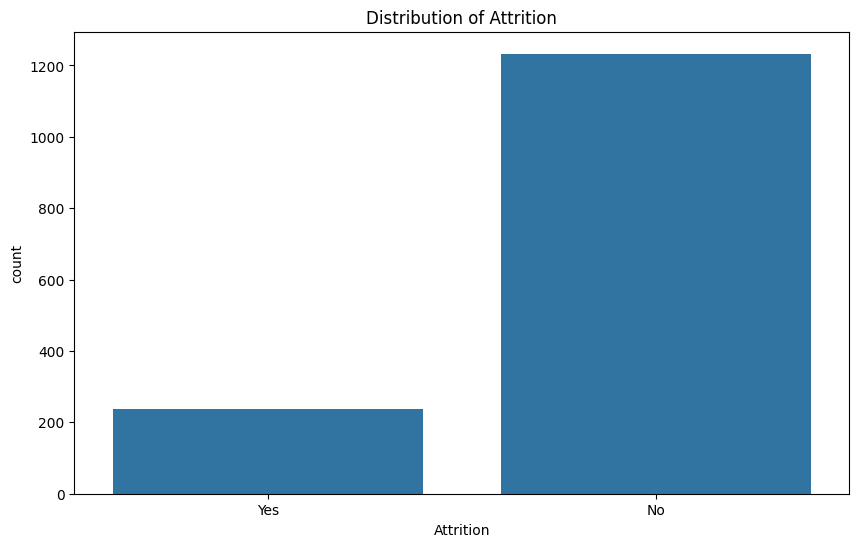

Distribution of Age:
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


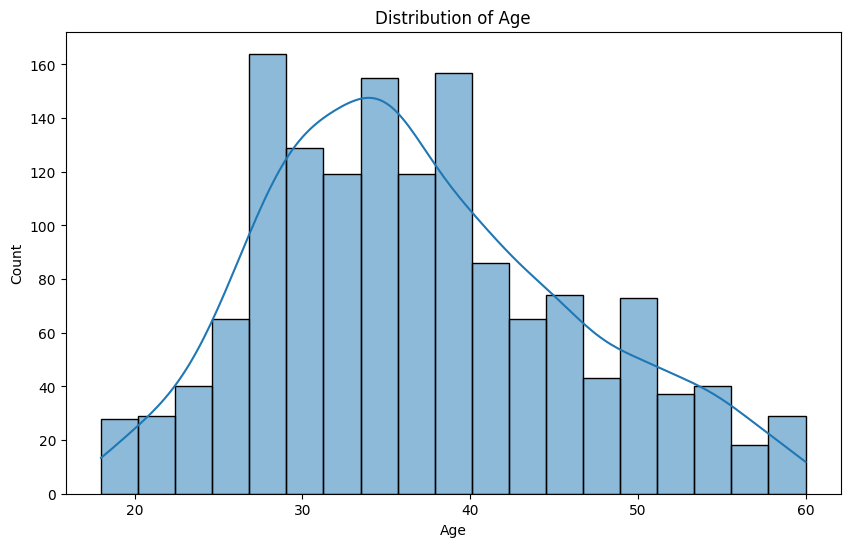

Distribution of MonthlyIncome:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


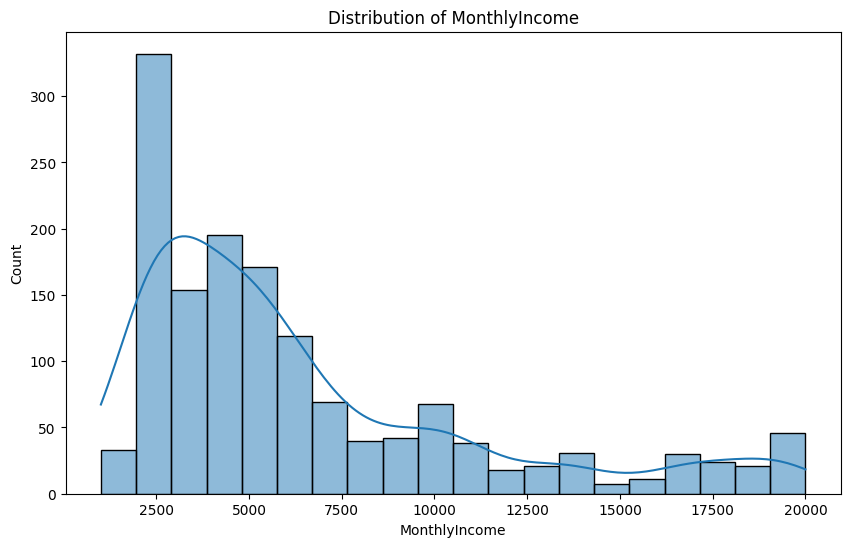

Distribution of NumCompaniesWorked:
count    1470.000000
mean        2.693197
std         2.498009
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         9.000000
Name: NumCompaniesWorked, dtype: float64


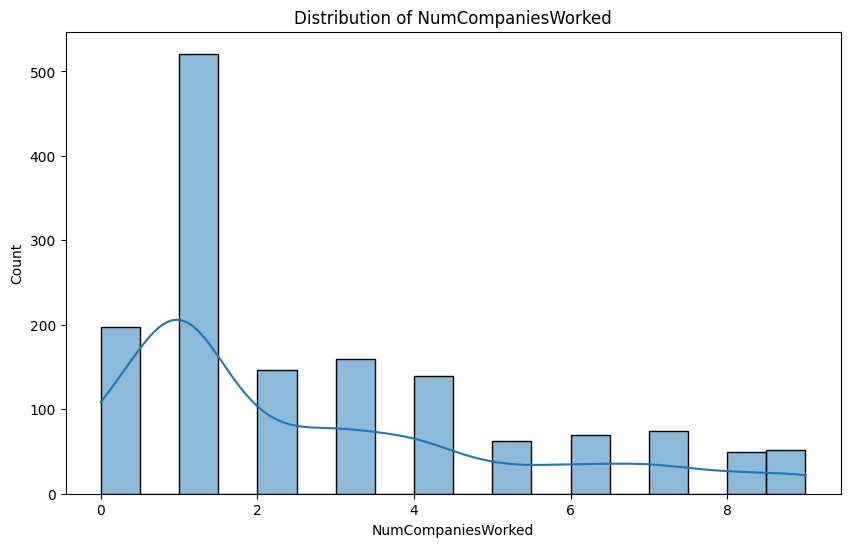

Distribution of TotalExperienceYears:
count    1470.000000
mean       11.279592
std         7.780782
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        40.000000
Name: TotalExperienceYears, dtype: float64


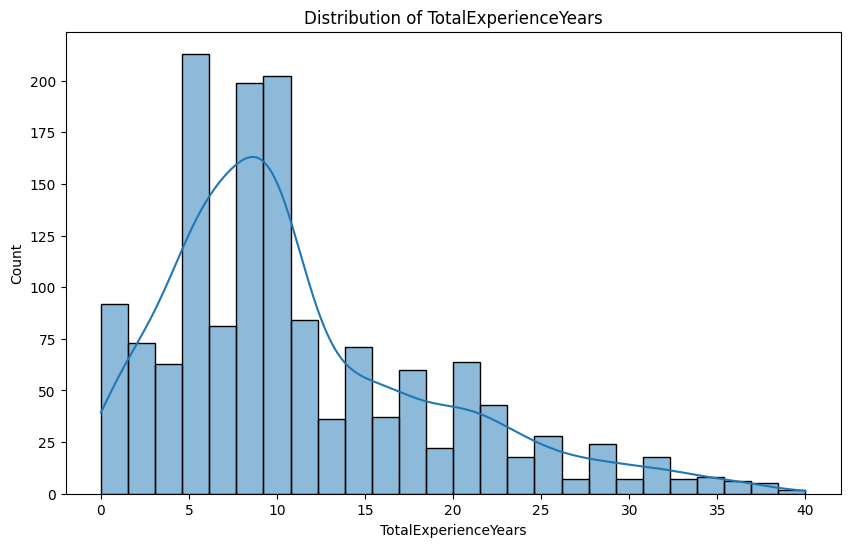

Distribution of YearsInCompany:
count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsInCompany, dtype: float64


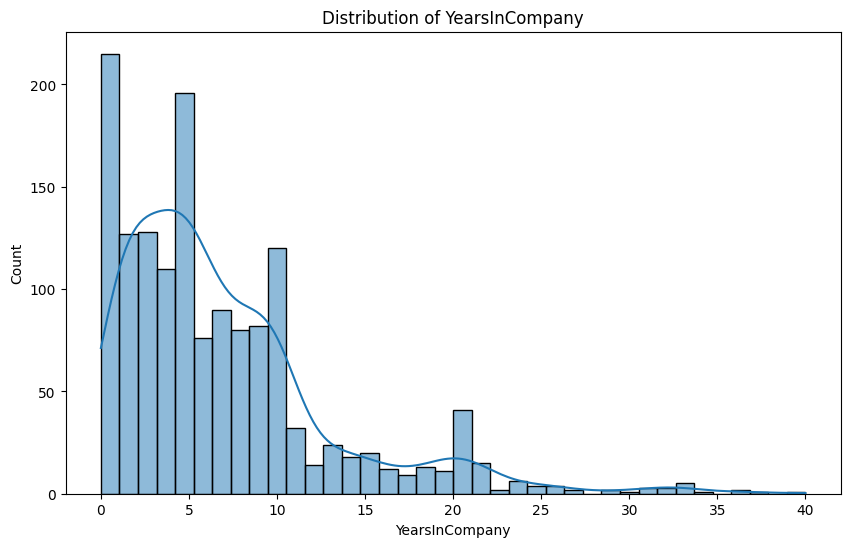

Distribution of YearsInCurrentRole:
count    1470.000000
mean        4.229252
std         3.623137
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        18.000000
Name: YearsInCurrentRole, dtype: float64


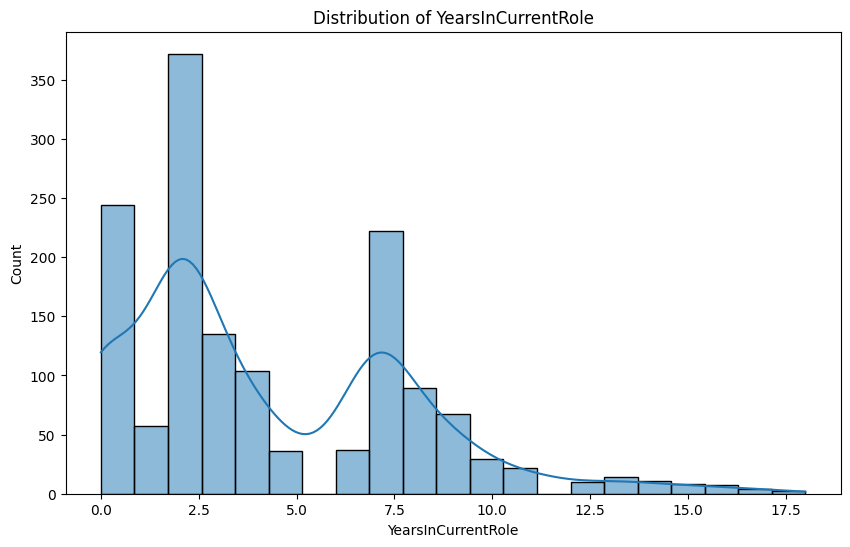

Distribution of YearsSinceLastPromotion:
count    1470.000000
mean        2.187755
std         3.222430
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        15.000000
Name: YearsSinceLastPromotion, dtype: float64


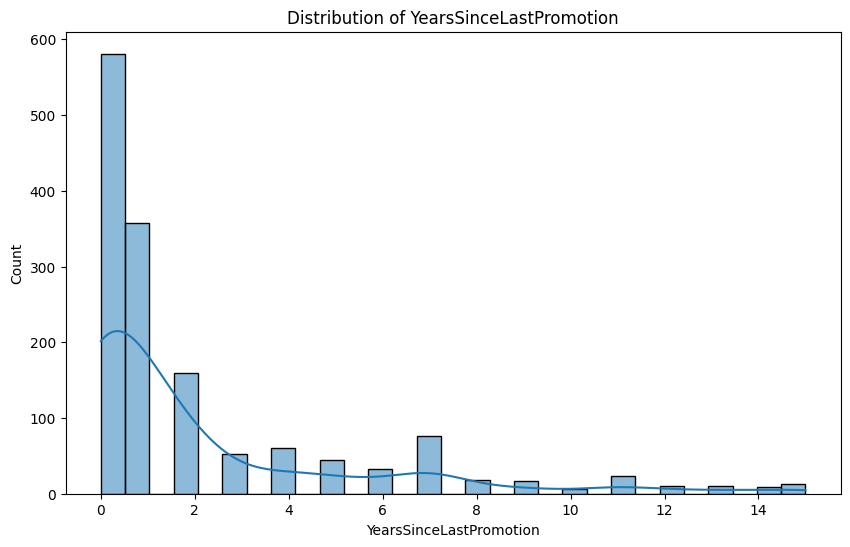

Distribution of YearsWithLineManager:
count    1470.000000
mean        4.123129
std         3.568136
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithLineManager, dtype: float64


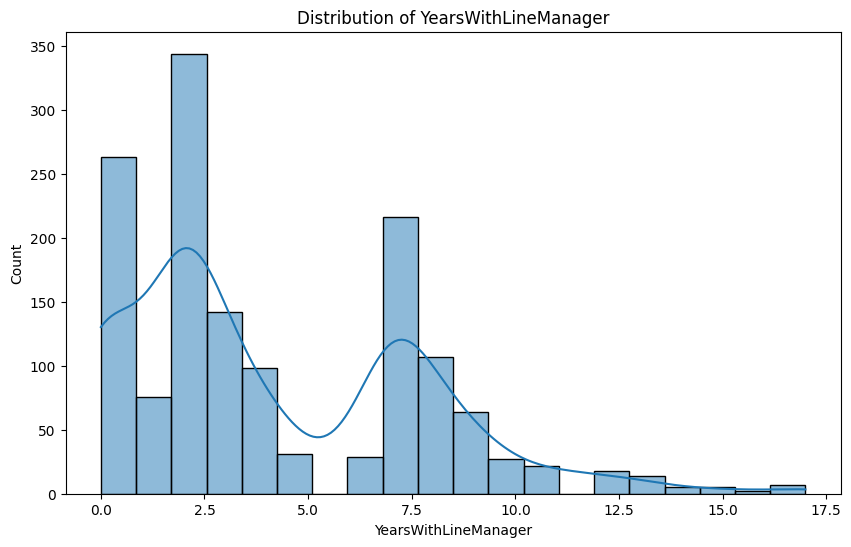

Correlation Matrix:
                              Age  MonthlyIncome  NumCompaniesWorked  \
Age                      1.000000       0.497855            0.299635   
MonthlyIncome            0.497855       1.000000            0.149515   
NumCompaniesWorked       0.299635       0.149515            1.000000   
TotalExperienceYears     0.680381       0.772893            0.237639   
YearsInCompany           0.311309       0.514285           -0.118421   
YearsInCurrentRole       0.212901       0.363818           -0.090754   
YearsSinceLastPromotion  0.216513       0.344978           -0.036814   
YearsWithLineManager     0.202089       0.344079           -0.110319   

                         TotalExperienceYears  YearsInCompany  \
Age                                  0.680381        0.311309   
MonthlyIncome                        0.772893        0.514285   
NumCompaniesWorked                   0.237639       -0.118421   
TotalExperienceYears                 1.000000        0.628133   
YearsI

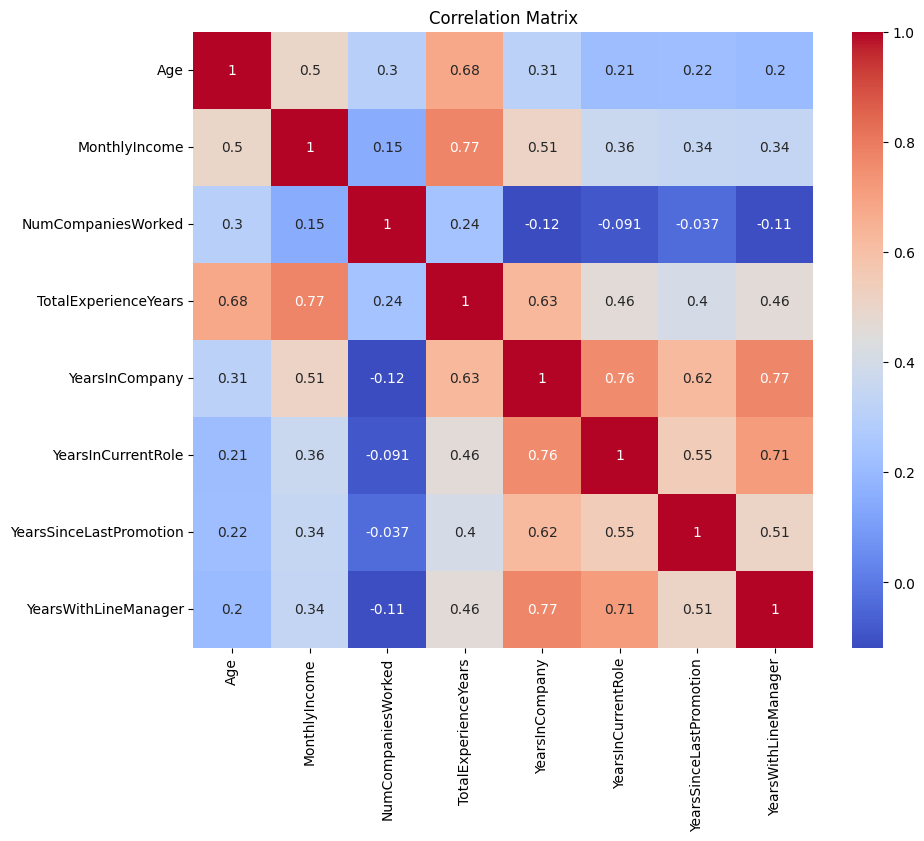

Satisfaction Level Distribution:
Satisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64


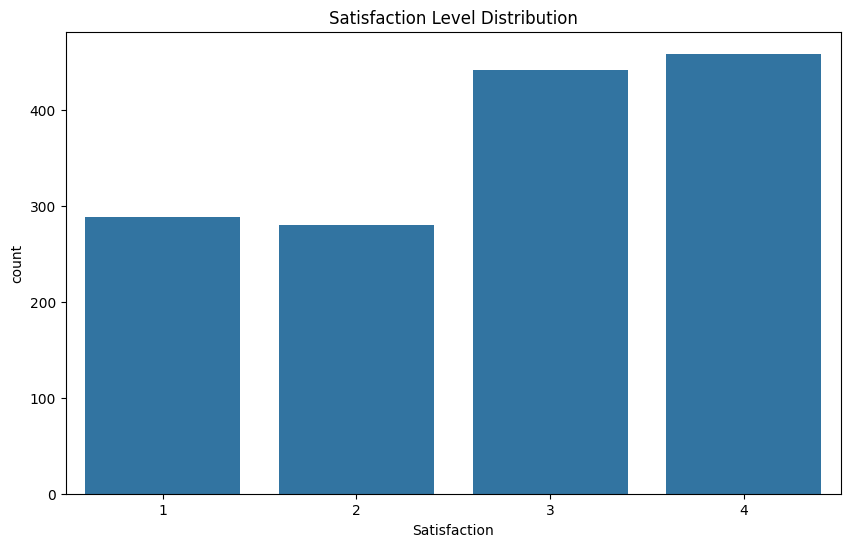

Attrition Rate:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


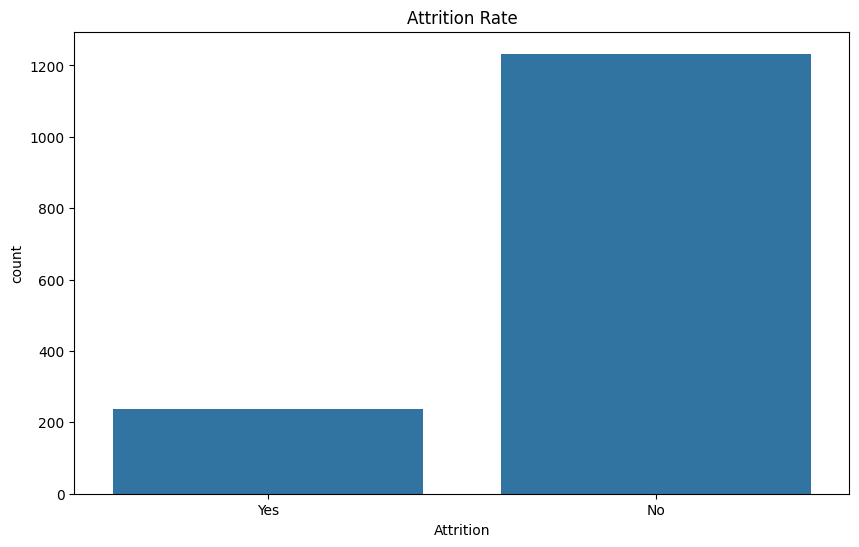

In [81]:
exec(extracted_code, globals())  # Run EDA

Missing Values:
EmployeeID                 0
Age                        0
Gender                     0
MaritalStatus              0
Education_Level            0
EducationField             0
BusinessTravel             0
Department                 0
Commute                    0
MonthlyIncome              0
MonthlyRate                0
DailyRate                  0
HourlyRate                 0
Grade                      0
Role                       0
Satisfaction               0
NumCompaniesWorked         0
OverTime                   0
TotalExperienceYears       0
YearsInCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithLineManager       0
Attrition                  0
pd                         0
plt                        0
sns                        0
eda                        0
dtype: int64
Distribution of Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64


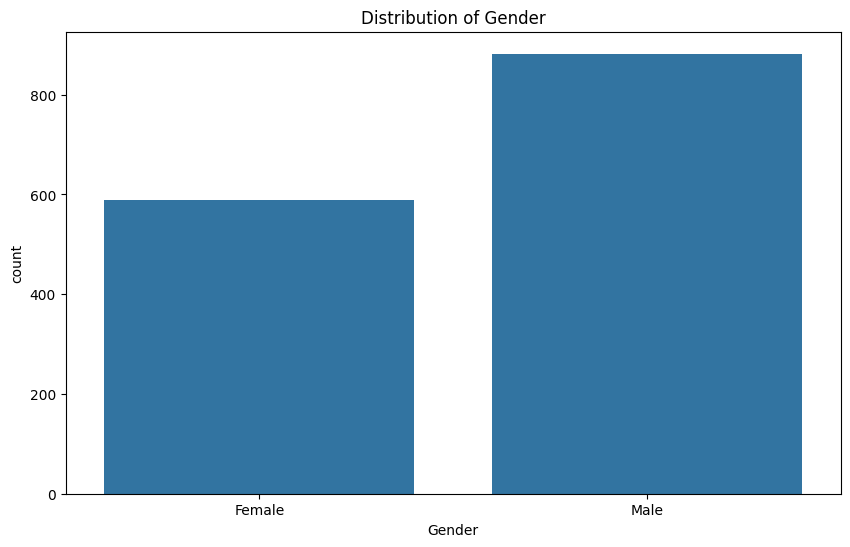

Distribution of MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


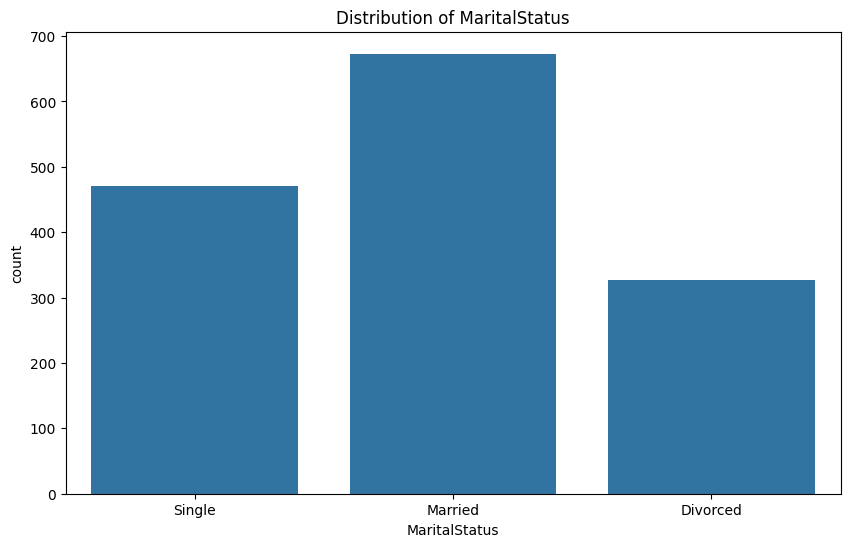

Distribution of Education_Level:
Education_Level
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64


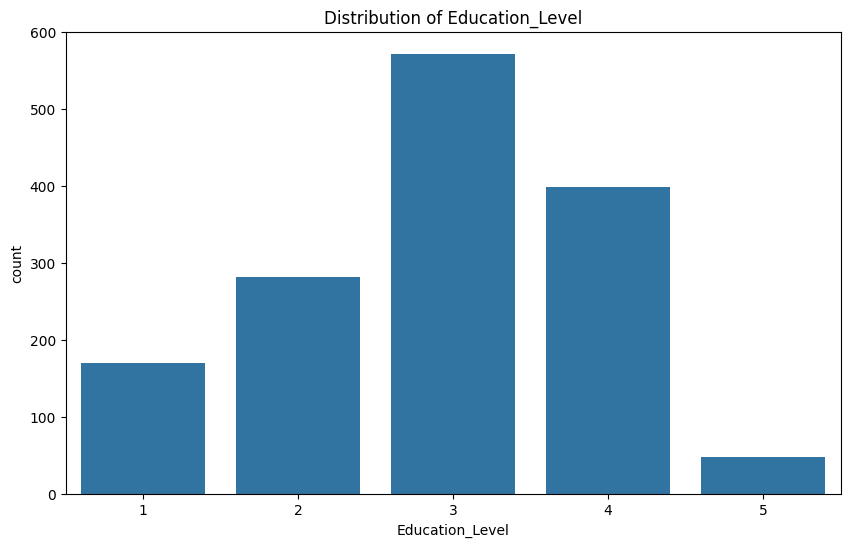

Distribution of EducationField:
EducationField
Social Sciences    606
Health Science     464
Business           159
Engineering        132
Other               82
Human Resources     27
Name: count, dtype: int64


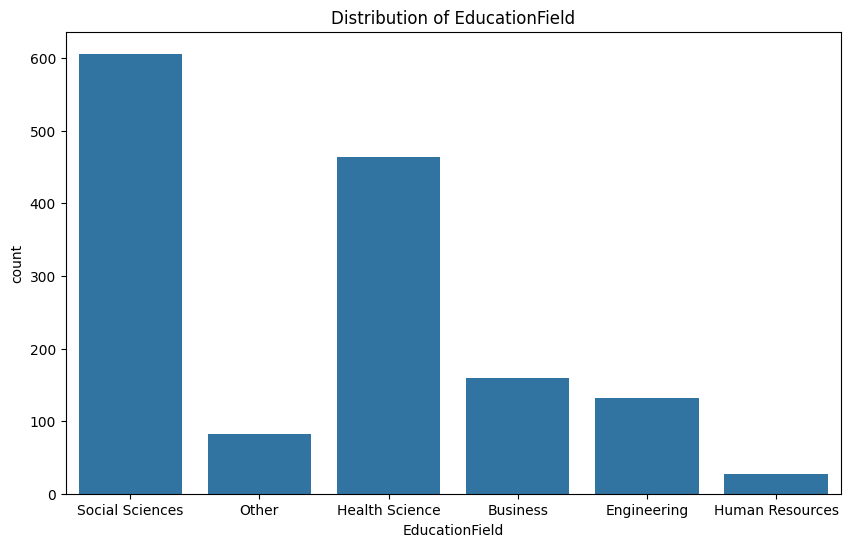

Distribution of BusinessTravel:
BusinessTravel
rarely        1043
frequently     277
none           150
Name: count, dtype: int64


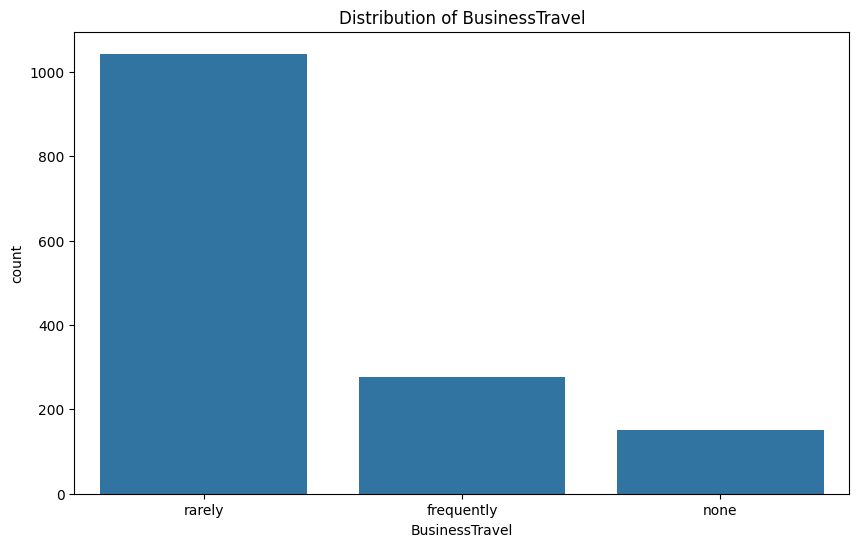

Distribution of Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


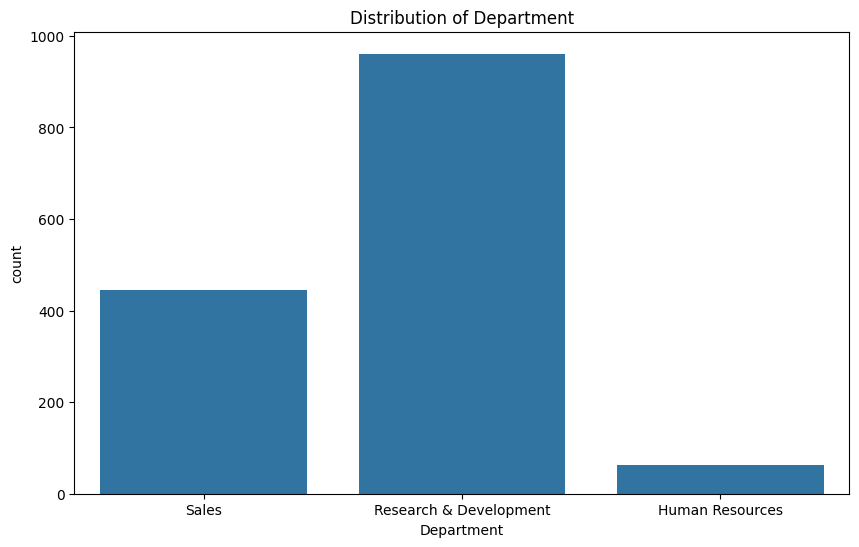

Distribution of Role:
Role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


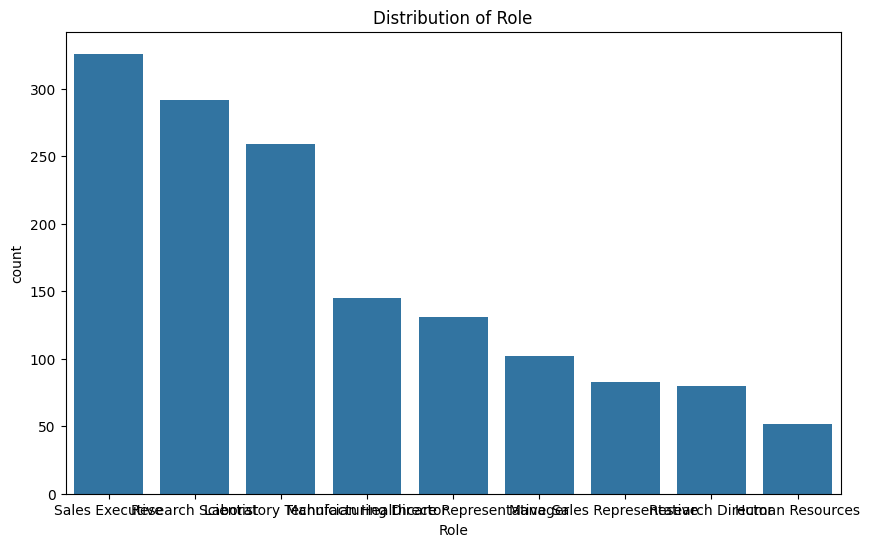

Distribution of OverTime:
OverTime
No     1054
Yes     416
Name: count, dtype: int64


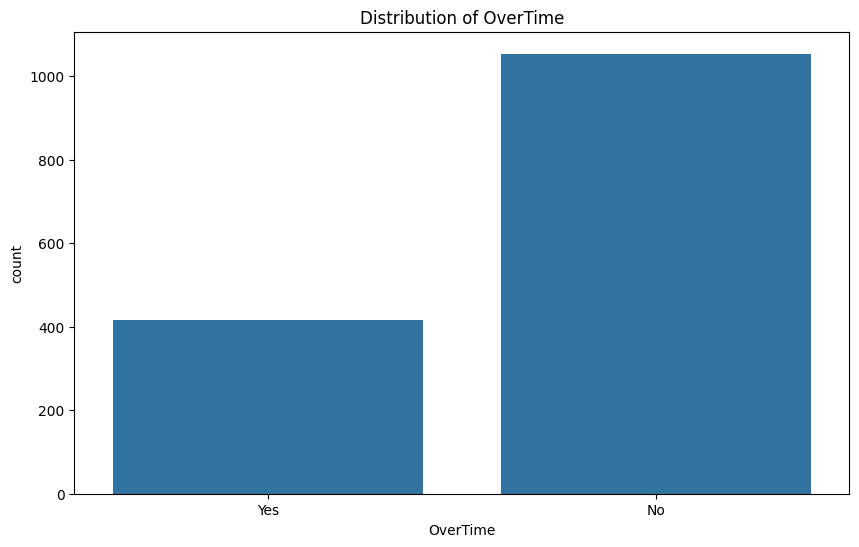

Distribution of Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


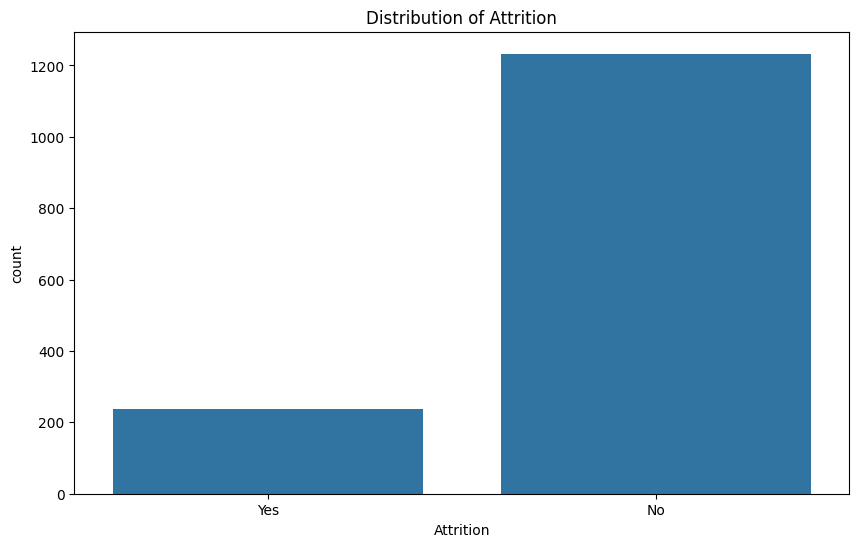

Distribution of Age:
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


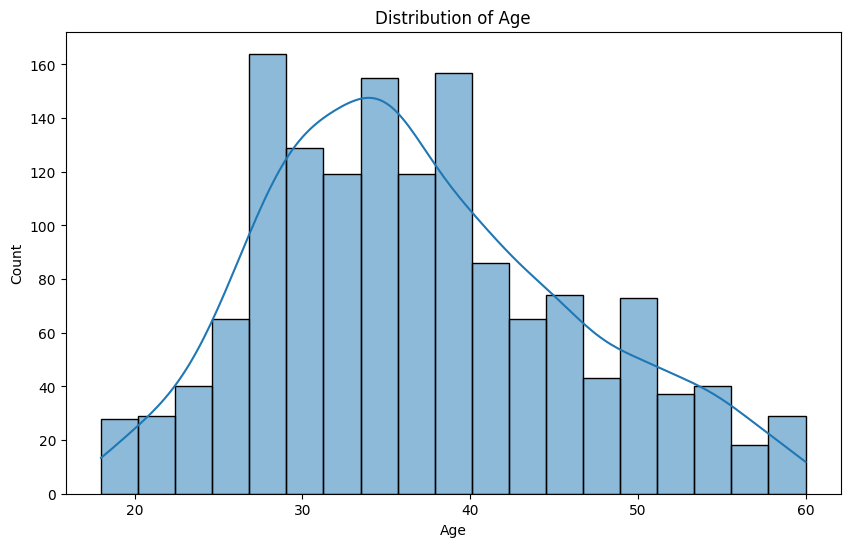

Distribution of MonthlyIncome:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


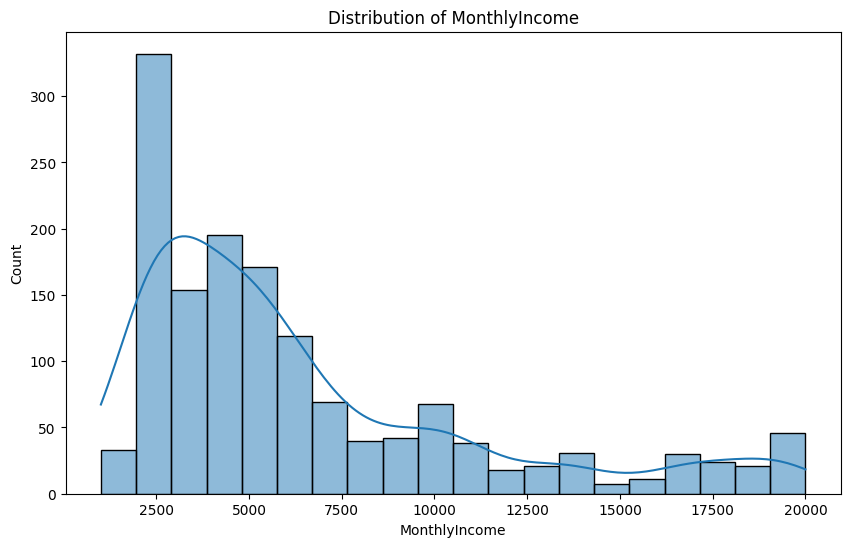

Distribution of NumCompaniesWorked:
count    1470.000000
mean        2.693197
std         2.498009
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         9.000000
Name: NumCompaniesWorked, dtype: float64


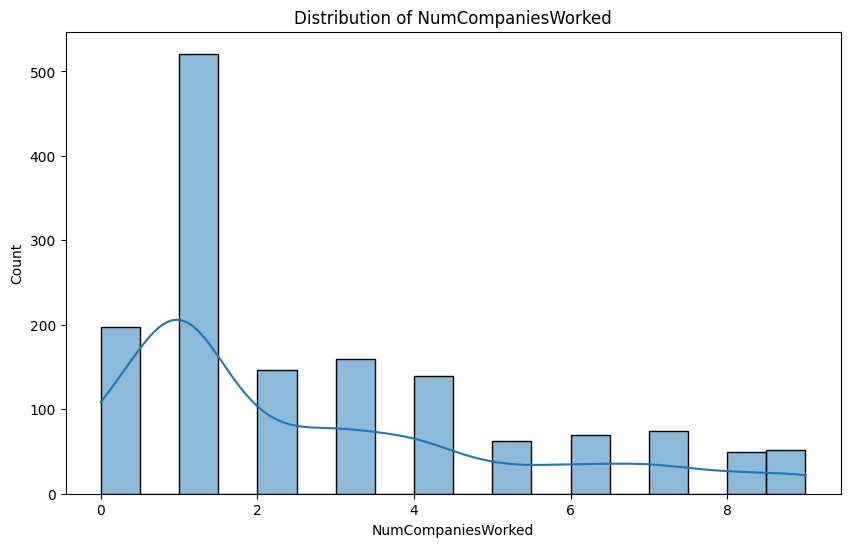

Distribution of TotalExperienceYears:
count    1470.000000
mean       11.279592
std         7.780782
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        40.000000
Name: TotalExperienceYears, dtype: float64


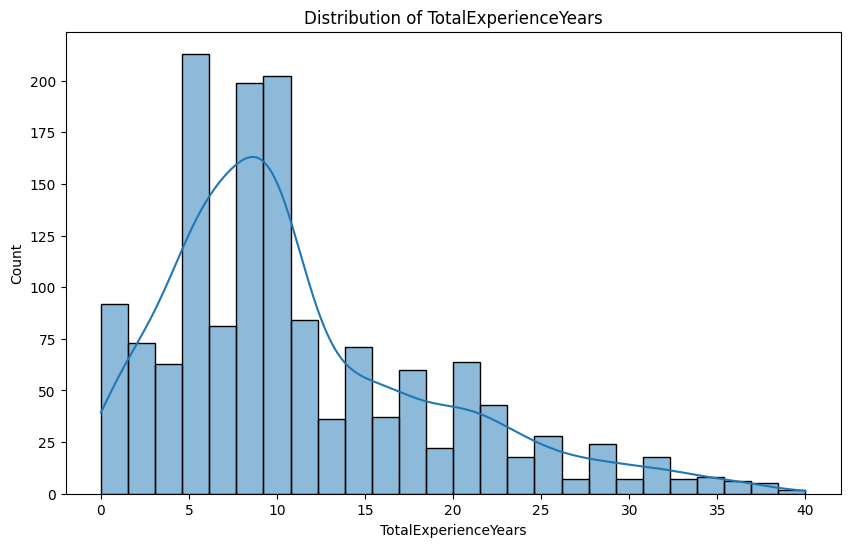

Distribution of YearsInCompany:
count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsInCompany, dtype: float64


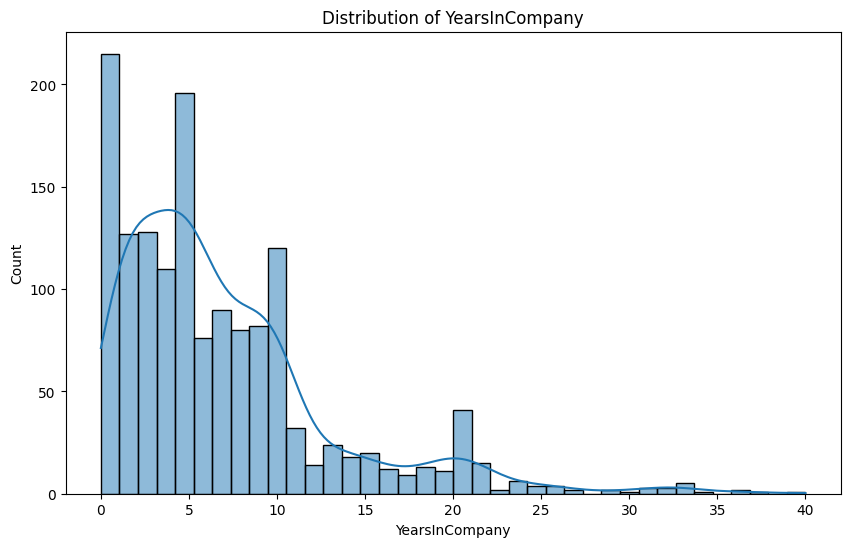

Distribution of YearsInCurrentRole:
count    1470.000000
mean        4.229252
std         3.623137
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        18.000000
Name: YearsInCurrentRole, dtype: float64


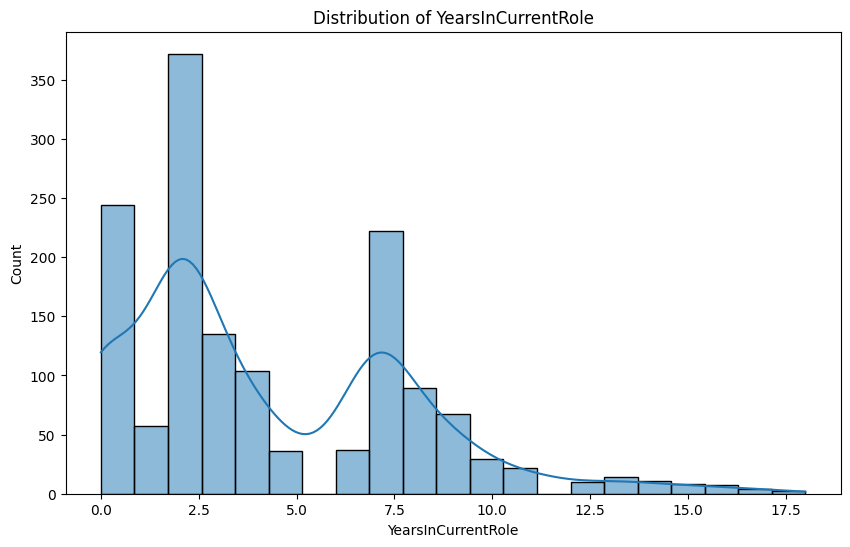

Distribution of YearsSinceLastPromotion:
count    1470.000000
mean        2.187755
std         3.222430
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        15.000000
Name: YearsSinceLastPromotion, dtype: float64


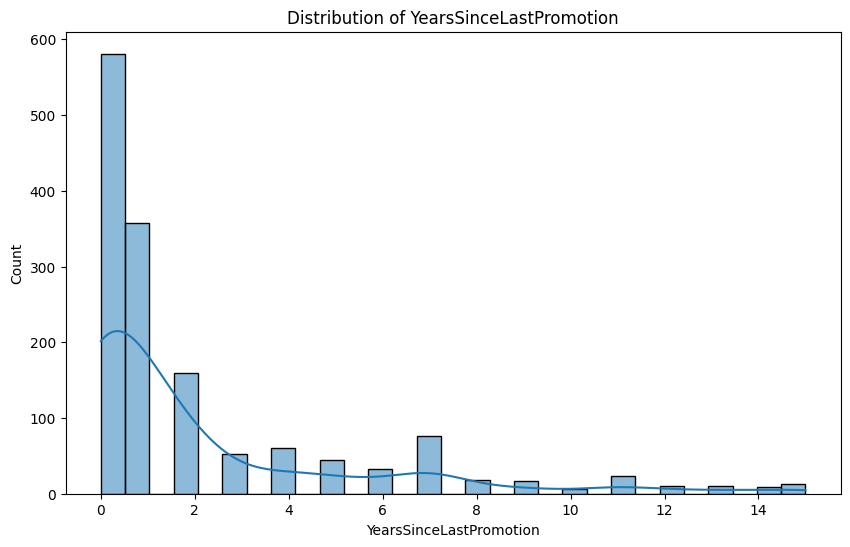

Distribution of YearsWithLineManager:
count    1470.000000
mean        4.123129
std         3.568136
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithLineManager, dtype: float64


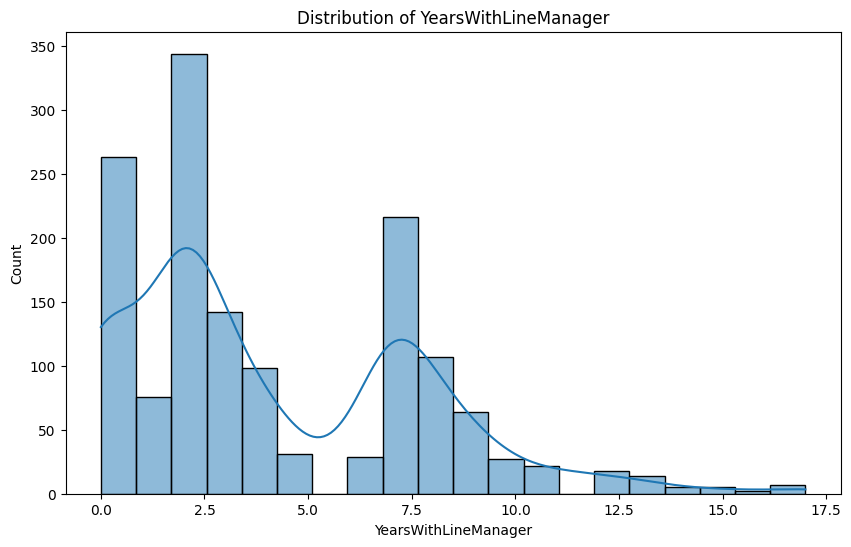

Correlation Matrix:
                              Age  MonthlyIncome  NumCompaniesWorked  \
Age                      1.000000       0.497855            0.299635   
MonthlyIncome            0.497855       1.000000            0.149515   
NumCompaniesWorked       0.299635       0.149515            1.000000   
TotalExperienceYears     0.680381       0.772893            0.237639   
YearsInCompany           0.311309       0.514285           -0.118421   
YearsInCurrentRole       0.212901       0.363818           -0.090754   
YearsSinceLastPromotion  0.216513       0.344978           -0.036814   
YearsWithLineManager     0.202089       0.344079           -0.110319   

                         TotalExperienceYears  YearsInCompany  \
Age                                  0.680381        0.311309   
MonthlyIncome                        0.772893        0.514285   
NumCompaniesWorked                   0.237639       -0.118421   
TotalExperienceYears                 1.000000        0.628133   
YearsI

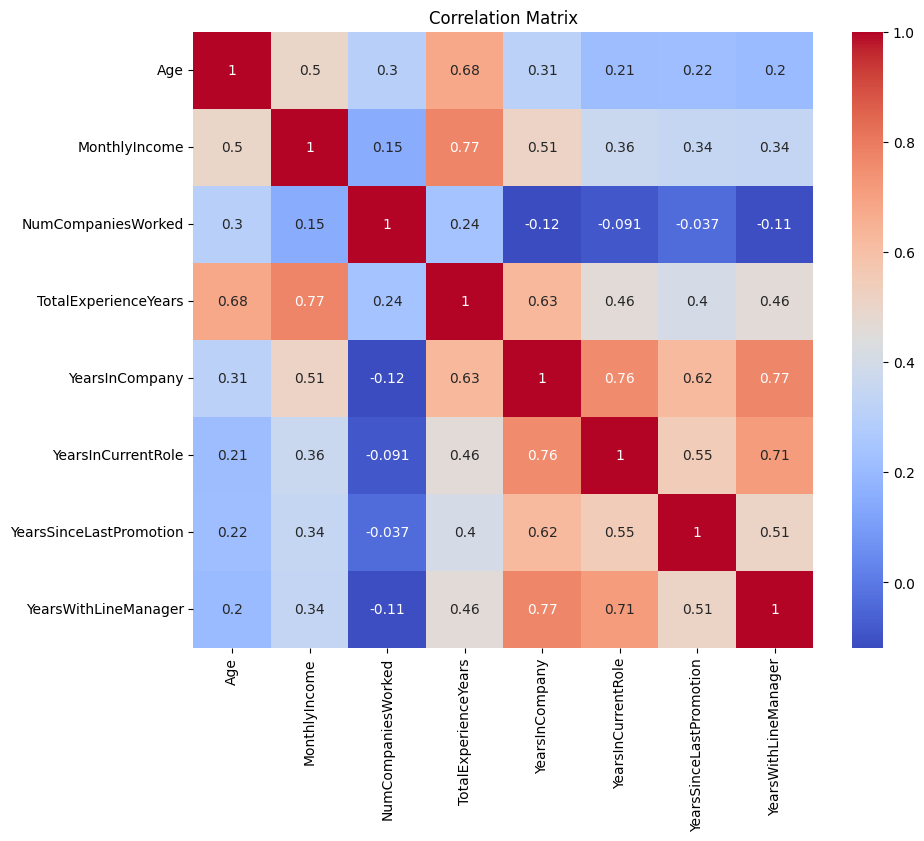

Satisfaction Level Distribution:
Satisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64


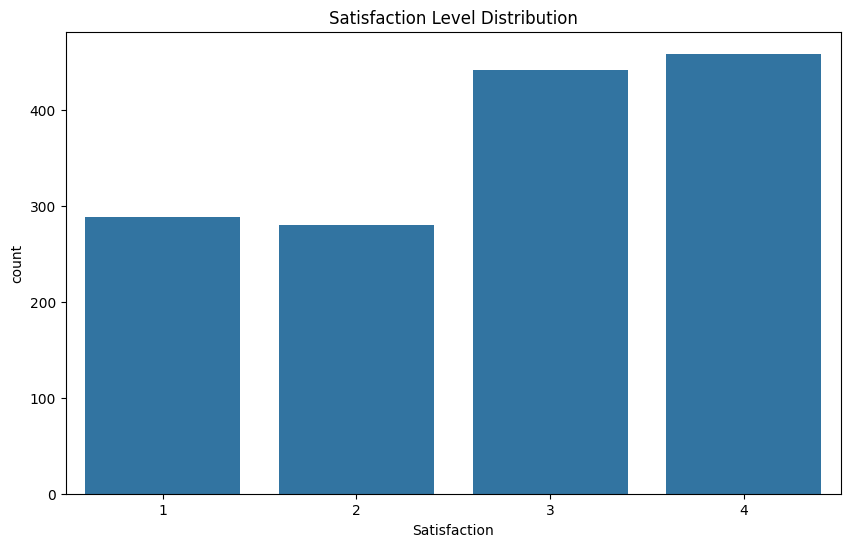

Attrition Rate:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


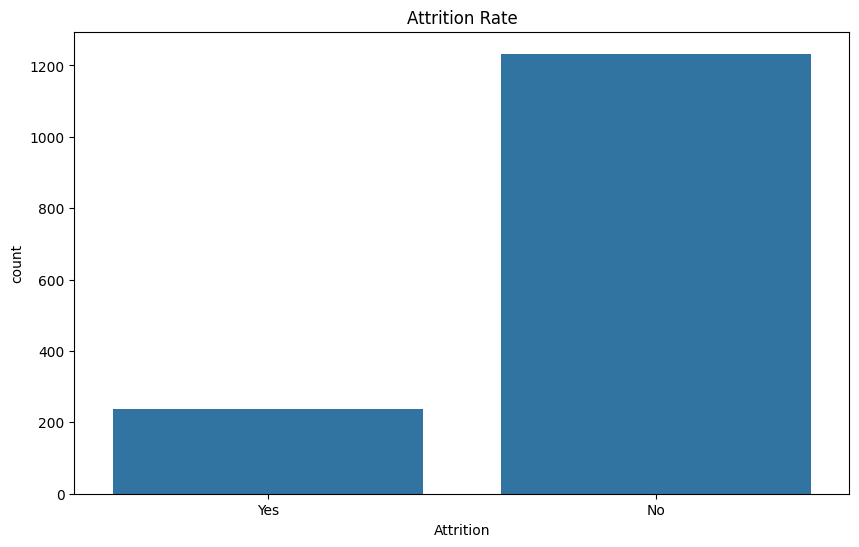

In [50]:
eda(df)

Missing Values:
EmployeeID                 0
Age                        0
Gender                     0
MaritalStatus              0
Education_Level            0
EducationField             0
BusinessTravel             0
Department                 0
Commute                    0
MonthlyIncome              0
MonthlyRate                0
DailyRate                  0
HourlyRate                 0
Grade                      0
Role                       0
Satisfaction               0
NumCompaniesWorked         0
OverTime                   0
TotalExperienceYears       0
YearsInCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithLineManager       0
Attrition                  0
pd                         0
plt                        0
sns                        0
eda                        0
dtype: int64
Distribution of Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64


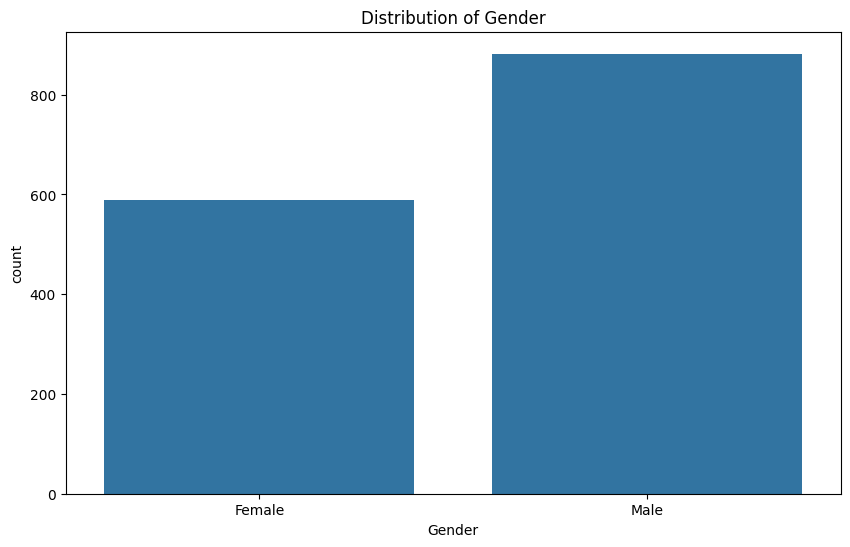

Distribution of MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


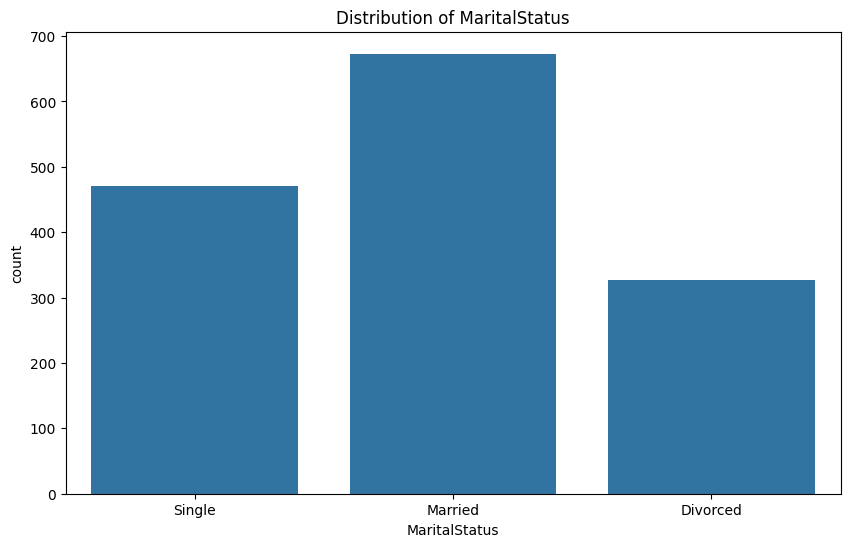

Distribution of Education_Level:
Education_Level
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64


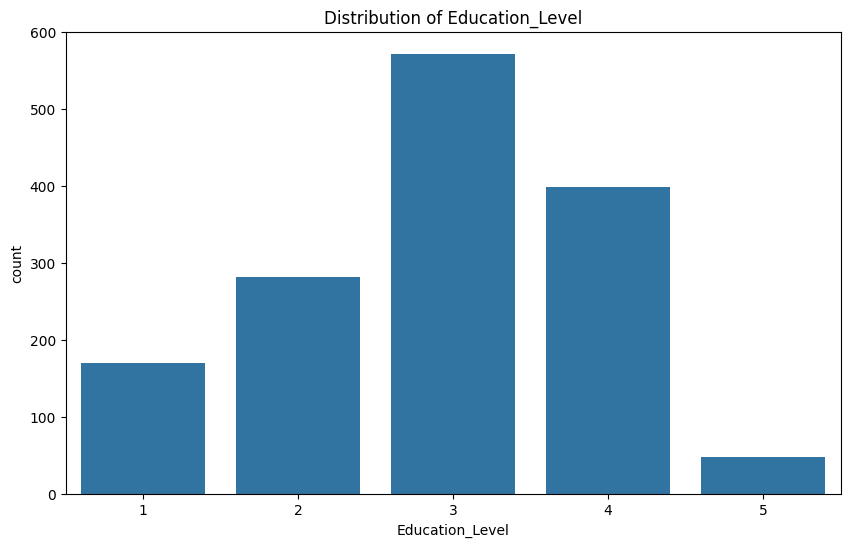

Distribution of EducationField:
EducationField
Social Sciences    606
Health Science     464
Business           159
Engineering        132
Other               82
Human Resources     27
Name: count, dtype: int64


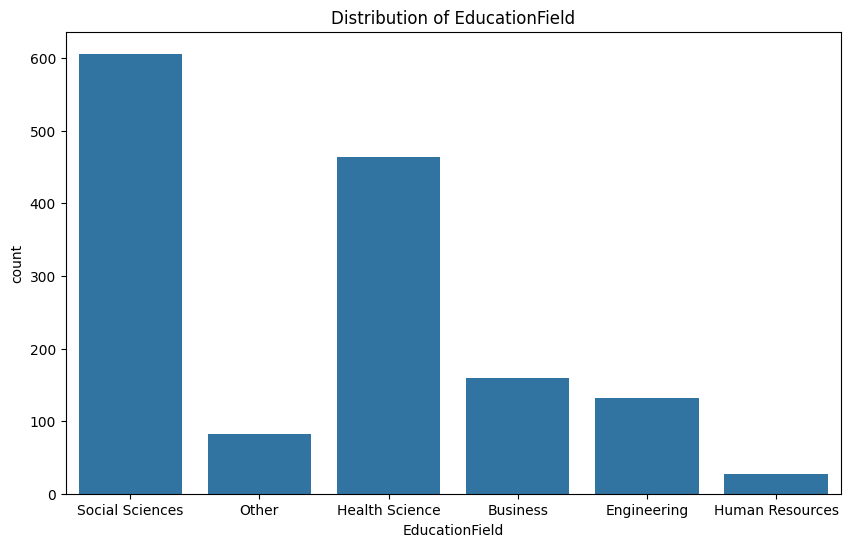

Distribution of BusinessTravel:
BusinessTravel
rarely        1043
frequently     277
none           150
Name: count, dtype: int64


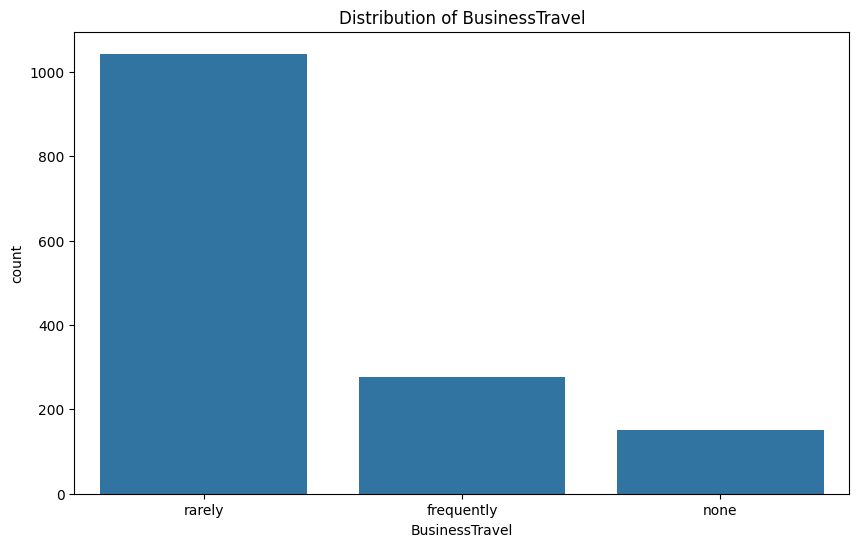

Distribution of Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


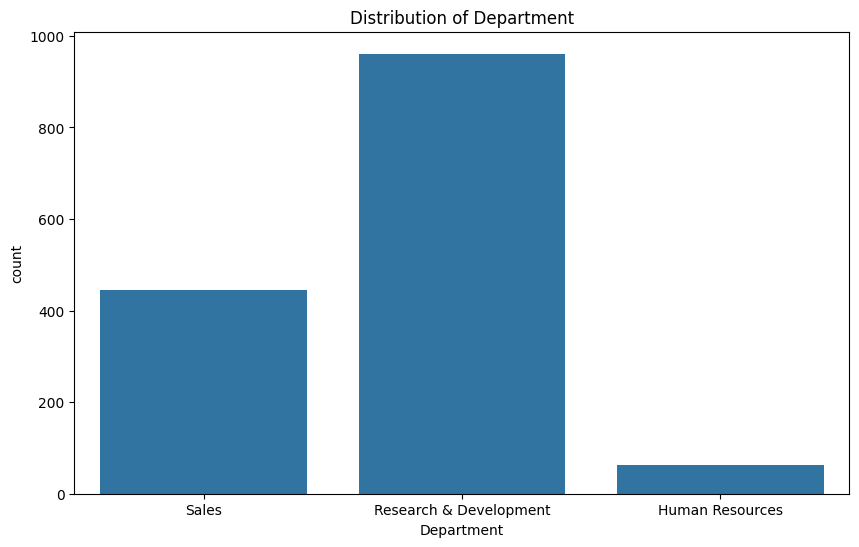

Distribution of Role:
Role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


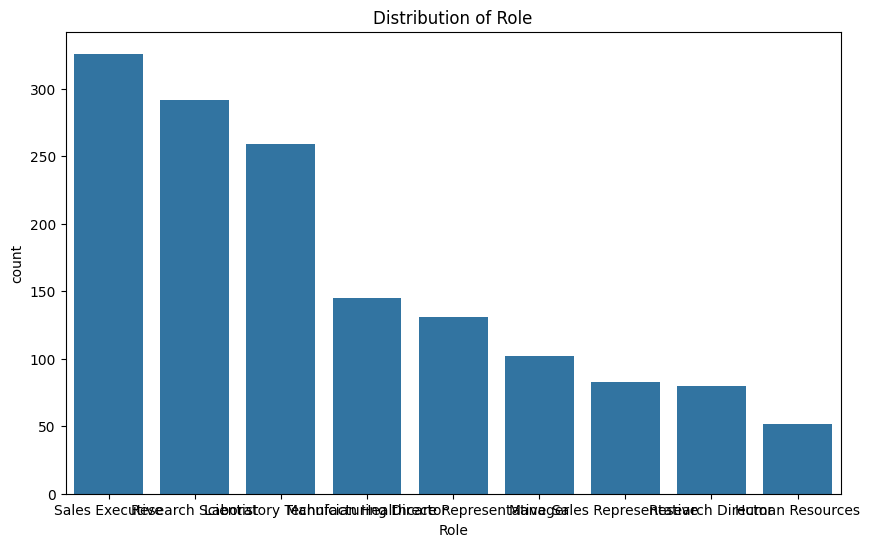

Distribution of OverTime:
OverTime
No     1054
Yes     416
Name: count, dtype: int64


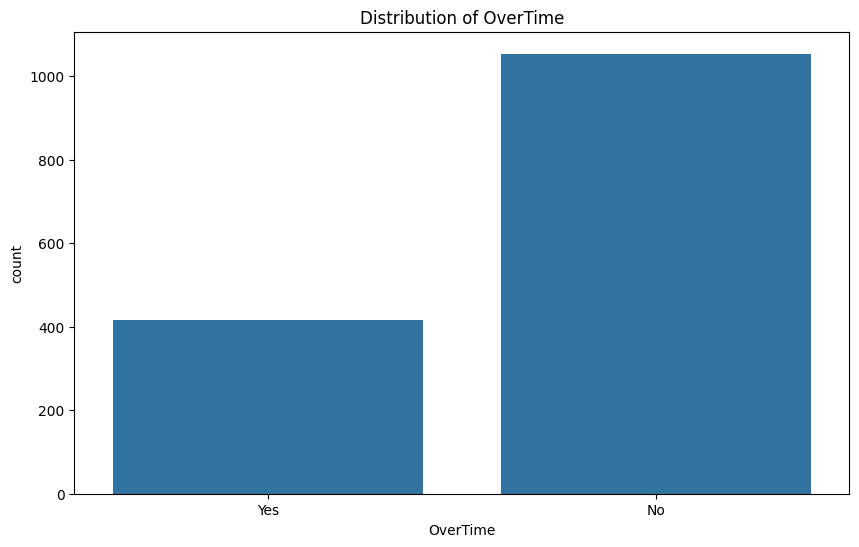

Distribution of Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


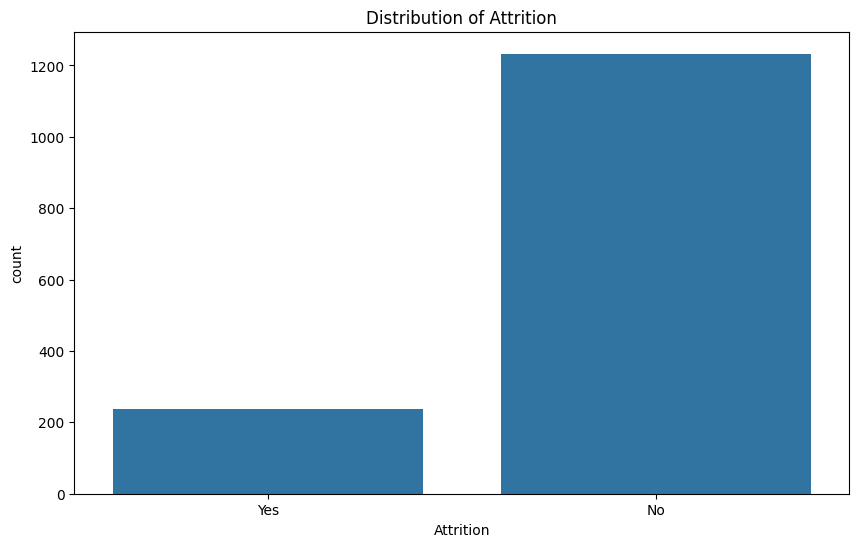

Distribution of Age:
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


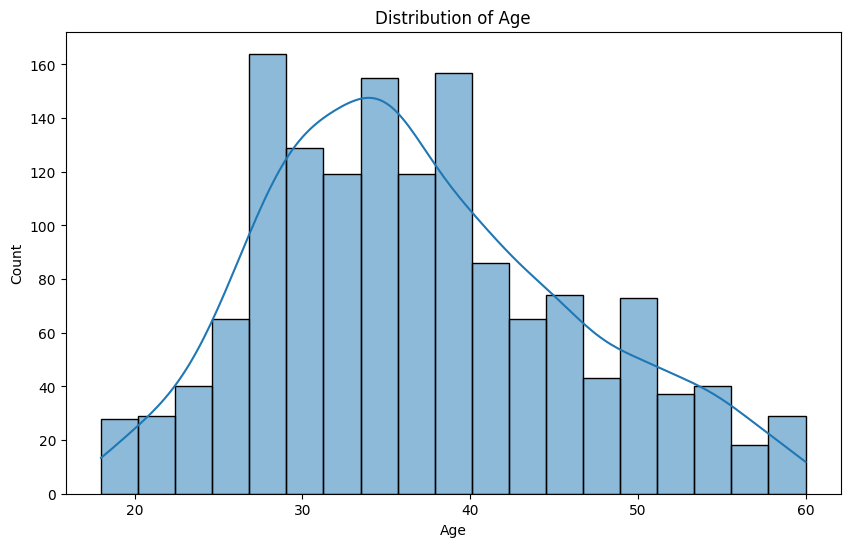

Distribution of MonthlyIncome:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


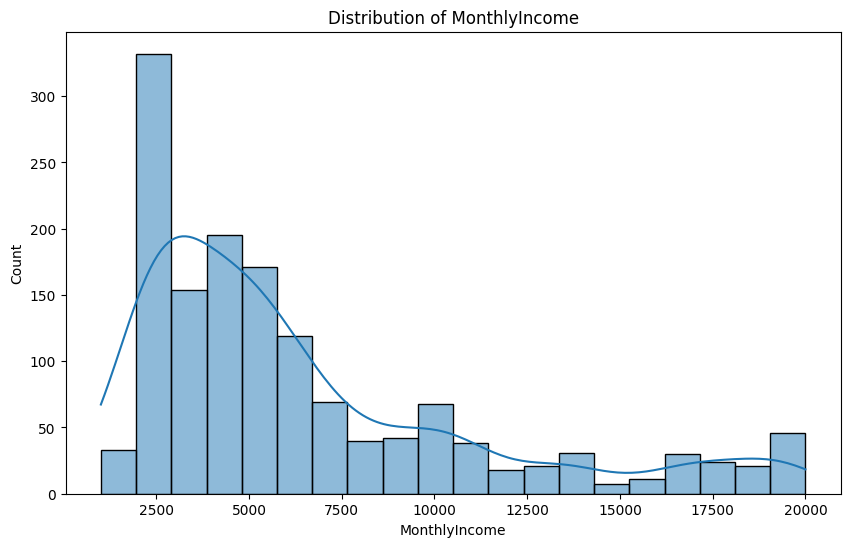

Distribution of NumCompaniesWorked:
count    1470.000000
mean        2.693197
std         2.498009
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         9.000000
Name: NumCompaniesWorked, dtype: float64


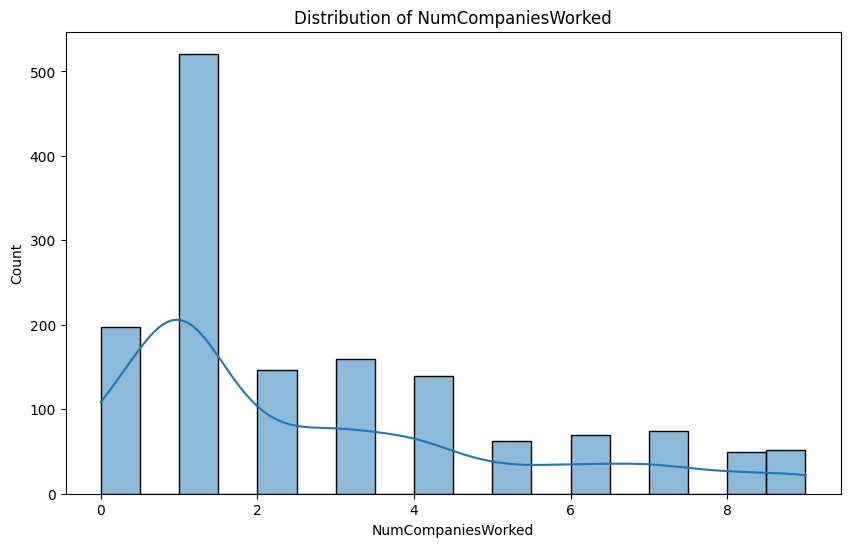

Distribution of TotalExperienceYears:
count    1470.000000
mean       11.279592
std         7.780782
min         0.000000
25%         6.000000
50%        10.000000
75%        15.000000
max        40.000000
Name: TotalExperienceYears, dtype: float64


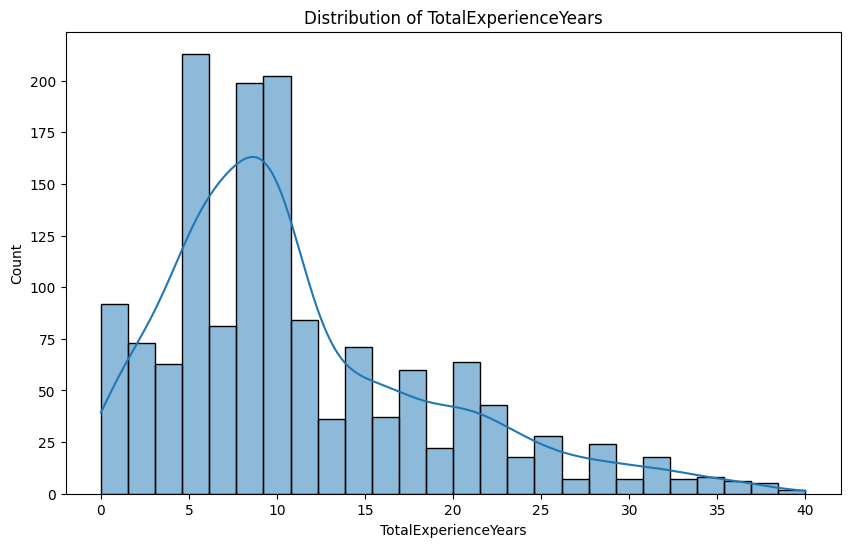

Distribution of YearsInCompany:
count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsInCompany, dtype: float64


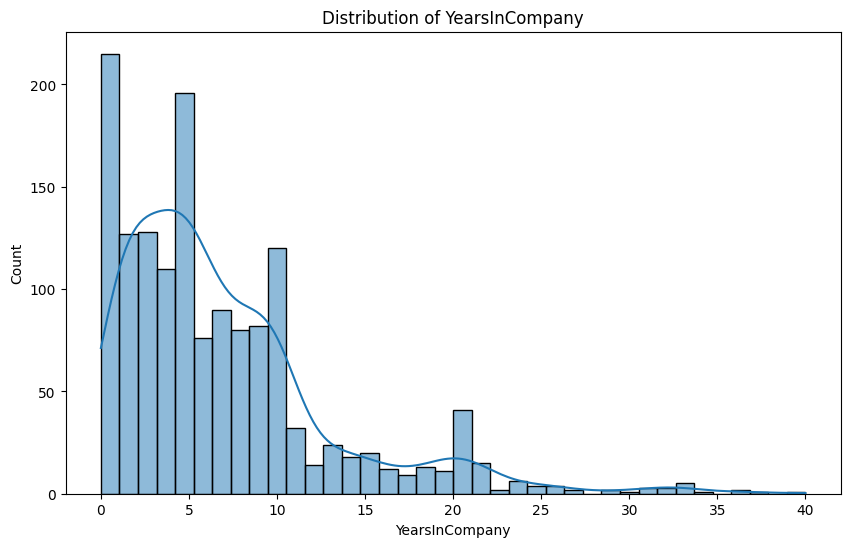

Distribution of YearsInCurrentRole:
count    1470.000000
mean        4.229252
std         3.623137
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        18.000000
Name: YearsInCurrentRole, dtype: float64


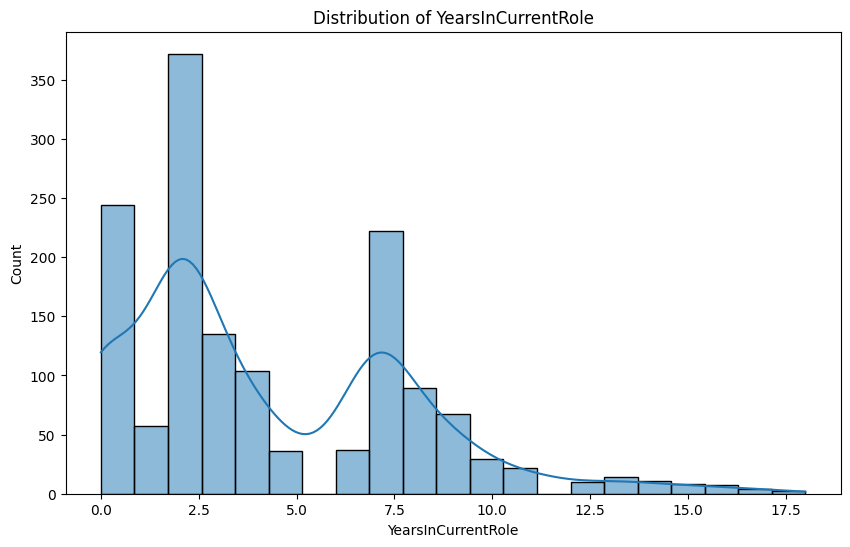

Distribution of YearsSinceLastPromotion:
count    1470.000000
mean        2.187755
std         3.222430
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        15.000000
Name: YearsSinceLastPromotion, dtype: float64


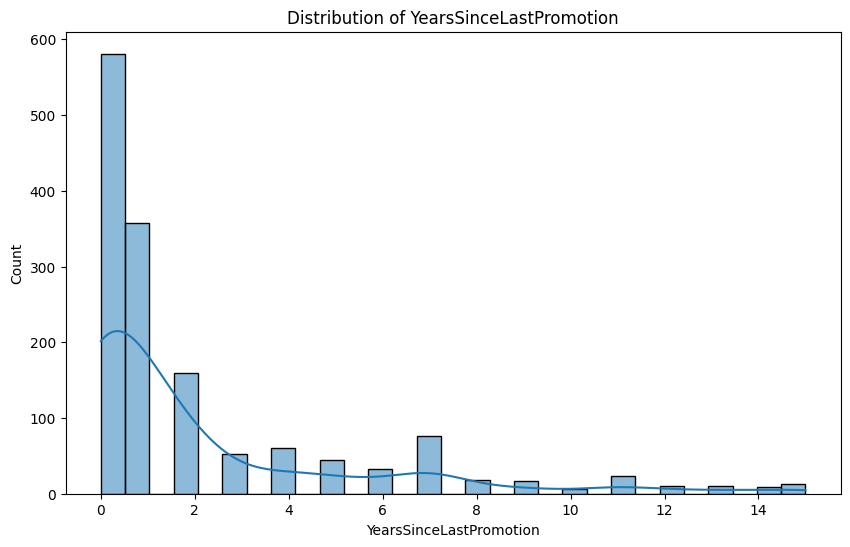

Distribution of YearsWithLineManager:
count    1470.000000
mean        4.123129
std         3.568136
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithLineManager, dtype: float64


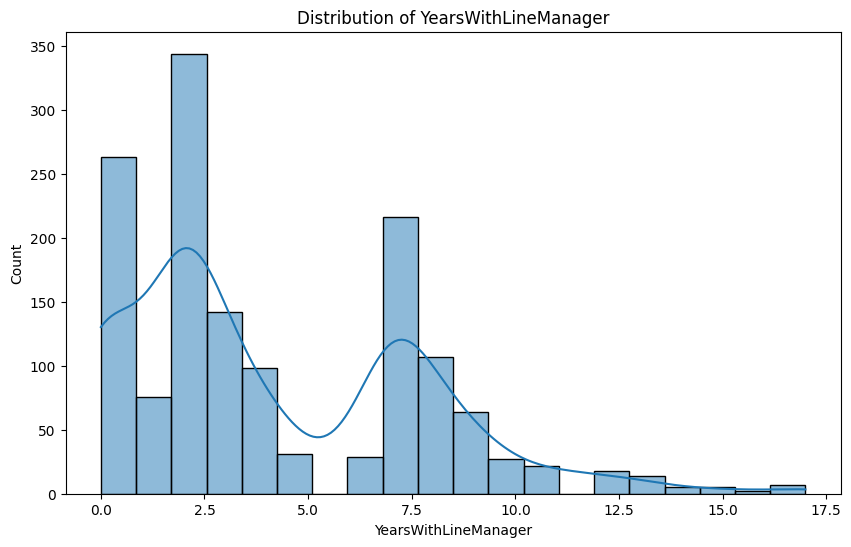

Correlation Matrix:
                              Age  MonthlyIncome  NumCompaniesWorked  \
Age                      1.000000       0.497855            0.299635   
MonthlyIncome            0.497855       1.000000            0.149515   
NumCompaniesWorked       0.299635       0.149515            1.000000   
TotalExperienceYears     0.680381       0.772893            0.237639   
YearsInCompany           0.311309       0.514285           -0.118421   
YearsInCurrentRole       0.212901       0.363818           -0.090754   
YearsSinceLastPromotion  0.216513       0.344978           -0.036814   
YearsWithLineManager     0.202089       0.344079           -0.110319   

                         TotalExperienceYears  YearsInCompany  \
Age                                  0.680381        0.311309   
MonthlyIncome                        0.772893        0.514285   
NumCompaniesWorked                   0.237639       -0.118421   
TotalExperienceYears                 1.000000        0.628133   
YearsI

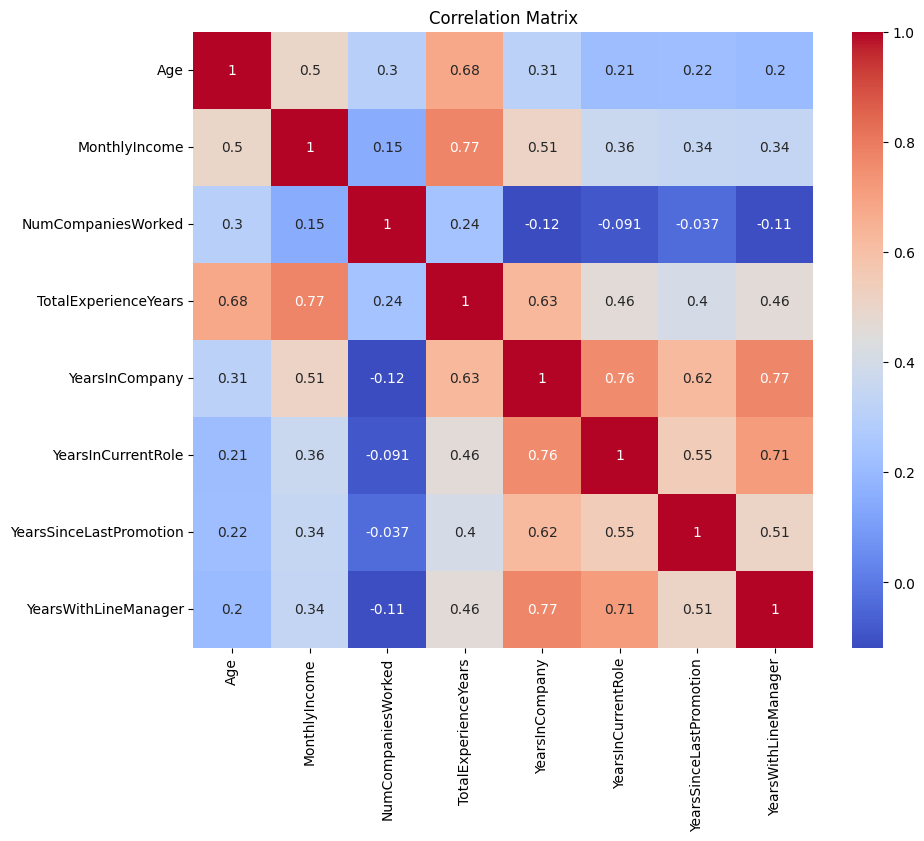

Satisfaction Level Distribution:
Satisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64


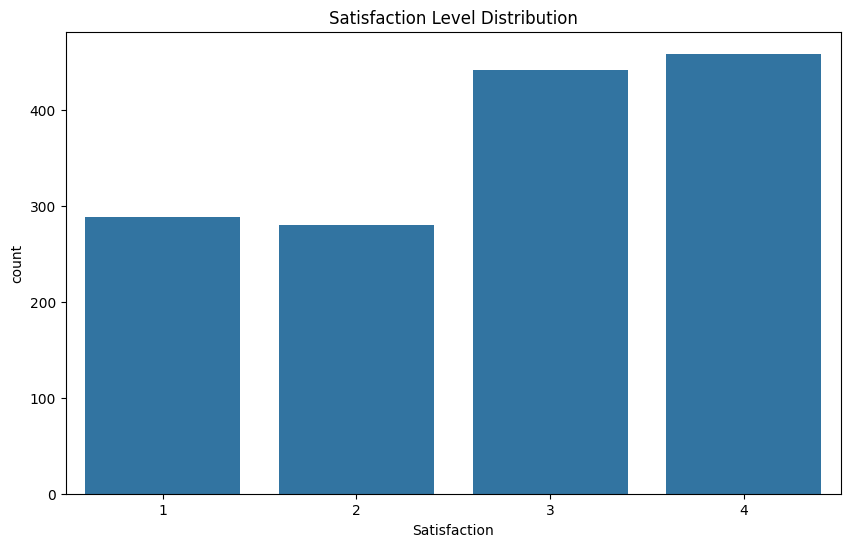

Attrition Rate:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


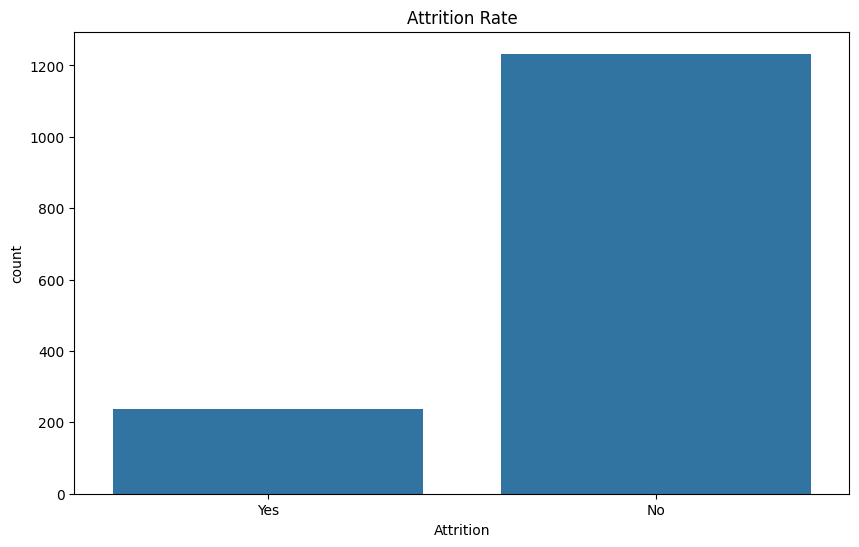

In [64]:
execution_context = {}  # Store df
exec(extracted_code, globals(), execution_context)  # Run EDA

In [74]:
execution_context.get("corr_matrix", None)

In [61]:
execution_context["df"]

,EmployeeID,Age,Gender,MaritalStatus,Education_Level,EducationField,BusinessTravel,Department,Commute,MonthlyIncome,...,TotalExperienceYears,YearsInCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithLineManager,Attrition,pd,plt,sns,eda
0,1,41,Female,Single,2,Social Sciences,rarely,Sales,1,5993,...,8,6,4,0,5,Yes,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
1,2,49,Male,Married,1,Social Sciences,frequently,Research & Development,8,5130,...,10,10,7,1,7,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
2,4,37,Male,Single,2,Other,rarely,Research & Development,2,2090,...,7,0,0,0,0,Yes,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
3,5,33,Female,Married,4,Social Sciences,frequently,Research & Development,3,2909,...,8,8,7,3,0,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
4,7,27,Male,Married,1,Health Science,rarely,Research & Development,2,3468,...,6,2,2,2,2,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,36,Male,Married,2,Health Science,frequently,Research & Development,23,2571,...,17,5,2,0,3,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
1466,2062,39,Male,Married,1,Health Science,rarely,Research & Development,6,9991,...,9,7,7,1,7,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
1467,2064,27,Male,Married,3,Social Sciences,rarely,Research & Development,4,6142,...,6,6,2,0,3,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>
1468,2065,49,Male,Married,3,Health Science,frequently,Sales,2,5390,...,17,9,6,0,8,No,<module 'pandas' from '/Users/sivasubramanians...,<module 'matplotlib.pyplot' from '/Users/sivas...,<module 'seaborn' from '/Users/sivasubramanian...,<function eda at 0x12b3d7dc0>


In [63]:
print(extracted_code)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df):
    # Check for missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Distribution of categorical variables
    categorical_cols = ['Gender', 'MaritalStatus', 'Education_Level', 'EducationField', 'BusinessTravel', 'Department', 'Role', 'OverTime', 'Attrition']
    for col in categorical_cols:
        print(f"Distribution of {col}:")
        print(df[col].value_counts())
        plt.figure(figsize=(10,6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.show()

    # Distribution of numerical variables
    numerical_cols = ['Age', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalExperienceYears', 'YearsInCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithLineManager']
    for col in numerical_cols:
        print(f"Distribution of {col}:")
        print(df[col].describe())
        plt.figure(figsize=(10,6))
        sn

# Working with different parser 🚀

In [11]:
from langchain_core.prompts import ChatPromptTemplate

AI_prompt=ChatPromptTemplate.from_messages(
    [
        ("system","You are an AI expert in HR Team. Provide me answer based on the question"),
        ("user","{input}")

    ]
)
AI_prompt

ChatPromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an AI expert in HR Team. Provide me answer based on the question'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])

In [19]:
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser

string_output_parser = StrOutputParser()

In [13]:
chain1=AI_prompt|g_llm|string_output_parser
chain2=AI_prompt|g_llm|JsonOutputParser

In [14]:
ai_response=chain1.invoke({"input":f"can you explain me what is this data is all about? {df}"})
ai_response

"**Overview of the Data**\n\nThe provided data appears to be a dataset related to employee information and behavior, likely collected for the purpose of analyzing employee attrition (i.e., turnover). The dataset contains 1470 rows, each representing a unique employee, and 24 columns, which can be categorized into several themes:\n\n### Demographic Information\n\n* `EmployeeID`: A unique identifier for each employee\n* `Age`: The age of the employee\n* `Gender`: The gender of the employee (Male or Female)\n* `MaritalStatus`: The marital status of the employee (Single or Married)\n* `Education_Level`: The level of education completed by the employee (1-4)\n* `EducationField`: The field of study for the employee's education (e.g., Social Sciences, Health Science, Other)\n\n### Work-Related Information\n\n* `BusinessTravel`: The frequency of business travel for the employee (rarely, frequently)\n* `Department`: The department in which the employee works (e.g., Sales, Research & Development

In [16]:
print(ai_response)

**Overview of the Data**

The provided data appears to be a dataset related to employee information and behavior, likely collected for the purpose of analyzing employee attrition (i.e., turnover). The dataset contains 1470 rows, each representing a unique employee, and 24 columns, which can be categorized into several themes:

### Demographic Information

* `EmployeeID`: A unique identifier for each employee
* `Age`: The age of the employee
* `Gender`: The gender of the employee (Male or Female)
* `MaritalStatus`: The marital status of the employee (Single or Married)
* `Education_Level`: The level of education completed by the employee (1-4)
* `EducationField`: The field of study for the employee's education (e.g., Social Sciences, Health Science, Other)

### Work-Related Information

* `BusinessTravel`: The frequency of business travel for the employee (rarely, frequently)
* `Department`: The department in which the employee works (e.g., Sales, Research & Development)
* `Commute`: Th

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

json_output_parser = JsonOutputParser()

json_prompt= PromptTemplate(template="you are a AI Expert engineer in HR team and provide answer to the user query\n{format_instructions}\n\n{query}\n",
                           input_variable=["query"],
                           partial_variables={"format_instructions":json_output_parser.get_format_instructions()},
                           )
json_prompt


json_chain=json_prompt|g_llm|json_output_parser

ai_response_json=json_chain.invoke({"query":f"Do you have any knowledge about the data {df}?"})
ai_response_json

{'data_description': {'number_of_rows': 1470,
  'number_of_columns': 24,
  'column_names': ['EmployeeID',
   'Age',
   'Gender',
   'MaritalStatus',
   'Education_Level',
   'EducationField',
   'BusinessTravel',
   'Department',
   'Commute',
   'MonthlyIncome',
   'Role',
   'Satisfaction',
   'NumCompaniesWorked',
   'OverTime',
   'TotalExperienceYears',
   'YearsInCompany',
   'YearsInCurrentRole',
   'YearsSinceLastPromotion',
   'YearsWithLineManager',
   'Attrition']},
 'data_types': {'EmployeeID': 'integer',
  'Age': 'integer',
  'Gender': 'categorical',
  'MaritalStatus': 'categorical',
  'Education_Level': 'integer',
  'EducationField': 'categorical',
  'BusinessTravel': 'categorical',
  'Department': 'categorical',
  'Commute': 'integer',
  'MonthlyIncome': 'integer',
  'Role': 'categorical',
  'Satisfaction': 'integer',
  'NumCompaniesWorked': 'integer',
  'OverTime': 'categorical',
  'TotalExperienceYears': 'integer',
  'YearsInCompany': 'integer',
  'YearsInCurrentRole':

In [43]:
ai_response_json.keys()

dict_keys(['data_description', 'data_types', 'summary_statistics'])

In [45]:
ai_response_json["data_description"].keys()

dict_keys(['number_of_rows', 'number_of_columns', 'column_names'])

In [47]:
ai_response_json=json_chain.invoke({"query":f"Can you tell me aboout the department wise monthly Income from the data set {df}? and answer only the values"})
ai_response_json

{'Sales': 5993.0, 'Research & Development': 5130.0}